<div align="center">

# Notebook 14 — CNN gelé sur scalogramme CWT + PCA fold-safe + Pantagruel / WavLM-Large

# Classification multi-classes FOCH

**Fusion tri-branche (Pantagruel + WavLM-Large + CNN ImageNet gelé sur scalogramme, réduit par PCA) — tête neuronale ou classifieur classique tuné en Optuna**

![Python](https://img.shields.io/badge/Python-3.12-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.11-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)
![PyWavelets](https://img.shields.io/badge/PyWavelets-CWT%20scalogramme-1f77b4?style=flat-square)
![torchvision](https://img.shields.io/badge/torchvision-CNN%20ImageNet%20gel%C3%A9-2ca02c?style=flat-square)
![scikit-learn](https://img.shields.io/badge/scikit--learn-PCA%20fold--safe-F7931E?style=flat-square&logo=scikitlearn)
![Optuna](https://img.shields.io/badge/Optuna-TPE-6A5ACD?style=flat-square)

</div>


## Synthèse de l'architecture tri-branche + PCA fold-safe

Copie de `11_0_foch_test_cwt_dinov2.ipynb` dont la partie représentation change : la branche résidu vocodeur (Vocos) et la branche Vision Transformer (DINOv2-Large) sont retirées, remplacées par un CNN ImageNet classique sur le même scalogramme CWT, réduit par PCA fold-safe. Le protocole d'évaluation (`StratifiedKFold` 5 plis patient-level, augmentation train-only, `FocalLoss`) est strictement inchangé.

| Branche | Modèle / source | Entraînable ? | Sortie |
|---|---|---|---|
| **1 — Pantagruel `speech-large-14K`** | dépôt local (`trust_remote_code=True`) | **gelée** | moyenne temporelle du `last_hidden_state` → dimension résolue à l'exécution |
| **2 — WavLM-Large** | `microsoft/wavlm-large`, répertoire local | **gelée** | moyenne temporelle du `last_hidden_state` → 1024-d |
| **3 — CNN ImageNet (torchvision, `RESNET_VARIANT`)** *(NOUVEAU)* | poids ImageNet, gelé | **gelée** | vecteur pooled avant `fc` (avant-dernière couche) → `RESNET_EMB_DIM`-d **brut**, puis réduit par PCA fold-safe |

**1 — Pourquoi sortir la CNN du modèle neuronal.** Contrairement à WavLM/Pantagruel, la CNN est gelée et sa sortie est **déterministe par fichier** (même scalogramme → même embedding, quel que soit le pli). On l'extrait donc **une seule fois pour tout le corpus** (mise en cache par `filepath`, comme le résidu vocodeur du notebook 11), plutôt que de la recalculer à chaque batch/epoch dans `forward()` — même résultat, beaucoup moins de calcul.

**2 — PCA fold-safe.** Les embeddings CNN bruts (2048-d pour resnet50) sont disproportionnés face à ~212 échantillons de train par pli. On standardise (`StandardScaler`) puis réduit (`PCA`, 95 % de variance expliquée, plafond dur `PCA_MAX_COMPONENTS`) — **ajustés sur le train du pli courant uniquement**, jamais sur la validation ni sur le dataset complet : même discipline que les statistiques de résidu vocodeur du notebook 11, appliquée ici à la CNN plutôt qu'à 6 scalaires faits main.

**3 — Deux modes de classifieur, togglables (`CLASSIFIER_MODE`).**
- `'neural_fusion'` **[DÉFAUT]** : la tête de fusion neuronale du template reçoit `[embedding Pantagruel brut, embedding WavLM-Large brut, embedding CNN réduit par PCA]`. Pantagruel et WavLM restent bruts (dimension déjà raisonnable, calculés à la volée dans `forward()`) ; seule la CNN, disproportionnée, passe par la PCA.
- `'classical_ml'` : la tête neuronale est remplacée par un classifieur classique (`CLASSICAL_MODEL` : Random Forest / XGBoost / SVM) tuné en Optuna/TPE, sur le modèle de `10_1_foch_residual_wavelet_svm_optuna.ipynb`. Les **trois** branches sont alors extraites une fois, réduites par PCA fold-safe et concaténées — un classifieur classique n'a pas de mécanisme de régularisation par gradient pour absorber ~3800-d bruts sur ~212 échantillons.

**4 — Portée du fine-tuning : aucune, sur les trois branches.** Pantagruel, WavLM-Large et la CNN sont intégralement gelés. En mode `neural_fusion`, seule la tête de fusion (et rien d'autre) reçoit un gradient. En mode `classical_ml`, il n'y a aucun réseau entraîné du tout — uniquement des features gelées + un classifieur scikit-learn/XGBoost.

> Les justifications détaillées accompagnent chaque section (Cellules 1, 4, 4c, 6, 7).


## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection des branches**. Le notebook met en œuvre un **classifieur tri-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**
<div align="center">

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Paralysie récurrentielle — pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Lésion de la muqueuse bénigne — support intermédiaire |
| `fuite glottique` | FOCH | Support le plus faible — classe minoritaire critique |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

</div>

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable des branches (`BACKBONE`)

Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding — la dimension de fusion est toujours la **somme** des dimensions des branches actives (pour la branche CNN, la dimension RÉELLE n'est connue qu'à l'exécution, par pli — cf. Cellule 7).

<div align="center">

| Preset | Pantagruel | WavLM-Large | CWT → CNN → PCA | Fusion |
|---|---|---|---|---|
| `pantagruel_wavlm_large_cwt_cnn` *(défaut de ce notebook)* | ✅ | ✅ 1024-d | ✅ *(dim. résolue par pli)* | somme des trois |
| `wavlm_large_cwt_cnn` | — | ✅ 1024-d | ✅ | somme des deux |
| `pantagruel_cwt_cnn` | ✅ | — | ✅ | somme des deux |
| `pantagruel_wavlm_large` | ✅ | ✅ 1024-d | — | somme des deux |
| `cwt_cnn_solo` | — | — | ✅ | dim. PCA seule (ablation) |
| `pantagruel_solo` | ✅ | — | — | dim. Pantagruel (ablation) |
| `wavlm_large_solo` | — | ✅ 1024-d | — | 1024-d (ablation) |

</div>

Les presets solo servent d'**ablations** : ils quantifient l'apport marginal de chaque branche. `pantagruel_wavlm_large_cwt_cnn` est le préset **par défaut** de ce notebook — les trois branches demandées pour cette itération. Ce notebook **retire** les branches résidu vocodeur (Vocos) et DINOv2-Large du notebook `11_0_foch_test_cwt_dinov2.ipynb` : la branche image devient un CNN ImageNet classique (torchvision), et WavLM passe de Base-Plus à **Large**.

> 🔌 **Chargement strictement local.** Cette machine n'a pas accès à `huggingface.co`. `HF_HUB_OFFLINE` et `TRANSFORMERS_OFFLINE` sont positionnés **avant** l'import de `transformers`, et tous les modèles HuggingFace sont chargés depuis des répertoires locaux avec `local_files_only=True`. Pantagruel exige en plus `trust_remote_code=True` : son code de modélisation est **présent dans le dépôt local**, il n'est donc jamais téléchargé. La CNN (torchvision) télécharge ses poids ImageNet depuis `download.pytorch.org` — un domaine DISTINCT, non vérifié comme bloqué sur cette machine ; `TORCH_HOME` fixe le cache si un contournement manuel s'avère nécessaire.

> 📦 **Dépendances ajoutées par ce notebook.** `pywt` (PyWavelets) pour la transformée en ondelettes continue, `torchvision` pour la branche CNN, `scikit-learn` (`StandardScaler`, `PCA`) pour la réduction fold-safe, et — uniquement en mode `classical_ml` — `optuna` (recherche TPE) et éventuellement `xgboost` si `CLASSICAL_MODEL='xgboost'` (absent de `requirements.txt` à ce jour).

### Dimension d'embedding de Pantagruel — résolue, jamais supposée

⚠️ **Piège de configuration.** Le `config.json` de Pantagruel expose **deux** attributs de dimension contradictoires :

- `hidden_size = 768` — valeur héritée par défaut de `PretrainedConfig`, **jamais utilisée** par le graphe du modèle ;
- `embed_dim = 1024` — dimension réellement employée par toutes les couches (`modeling_pantagruel_uni.py` construit chaque bloc à partir de `config.embed_dim`).

Lire `config.hidden_size`, réflexe habituel avec les modèles HuggingFace, donnerait ici une dimension de fusion **fausse de 256**. La Cellule 1 résout donc la dimension via `_resolve_pantagruel_dim()` (priorité à `embed_dim`) et **signale explicitement** la divergence ; la Cellule 6 la **revérifie sur une passe avant réelle** et lève une assertion en cas d'écart. Aucune dimension Pantagruel n'est écrite en dur dans ce notebook.

### Branche CNN sur scalogramme CWT — dimension d'image résolue, PCA fold-safe

`RESNET_VARIANT` pilote à la fois l'architecture ET les poids ImageNet (torchvision associe un jeu de poids « officiel » par variante) — `RESNET_EMB_DIM` (dimension avant `fc`) et `RESNET_IMG_SIZE` sont RÉSOLUS depuis les métadonnées du checkpoint choisi (`weights.transforms()`), jamais supposés à 2048/224. `CWT_WAVELET` (Morlet complexe), `CWT_FREQ_MIN`/`CWT_FREQ_MAX` et `CWT_N_SCALES` pilotent le calcul du scalogramme (Cellule 4) — inchangés depuis le notebook 11.

Contrairement à Pantagruel/WavLM (bruts, concaténés tels quels), l'embedding CNN brut (`RESNET_EMB_DIM`-d, disproportionné face à ~212 échantillons/pli) est **réduit par PCA fold-safe** : `StandardScaler` puis `PCA` ajustés **uniquement sur le train du pli courant** (`PCA_VARIANCE_TARGET=0.95` de variance expliquée, plafonné à `PCA_MAX_COMPONENTS=30`) — cf. Cellule 4/7 pour l'implémentation complète.

### Deux modes de classifieur (`CLASSIFIER_MODE`)

Équivalent du preset `FEATURE_SET` de `10_1_foch_residual_wavelet_svm_optuna.ipynb`, appliqué ici au choix du classifieur plutôt qu'aux features :
- `'neural_fusion'` **[DÉFAUT]** — tête de fusion neuronale (Cellule 6), entrée = Pantagruel brut + WavLM-Large brut + CNN réduit par PCA.
- `'classical_ml'` — classifieur classique (`CLASSICAL_MODEL` : Random Forest / XGBoost / SVM) tuné en Optuna/TPE (Cellule 7), entrée = concaténation des TROIS embeddings réduits par PCA fold-safe.

### Budget mémoire

Les deux encodeurs de parole (Pantagruel, WavLM-Large) sont gelés et exécutés sous `torch.no_grad()` : aucune activation intermédiaire n'est conservée pour la rétropropagation, le coût VRAM est celui d'une inférence. La CNN (branche 3) est **hors du modèle** (extraite une seule fois en Cellule 4, jamais rappelée pendant l'entraînement) : elle ne contribue **pas** à la VRAM de pointe mesurée en Cellule 6b, contrairement à DINOv2 dans le notebook 11. La **sonde VRAM (Cellule 6b)** reste à relancer après tout changement de preset pour vérifier que le `BATCH_SIZE` courant tient sur cette machine (**RTX PRO 2000 portable, 8 Go**). Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os

# ── Mode strictement HORS LIGNE (Hugging Face) ───────────────────────────────
# Cette machine n'a pas accès à huggingface.co. Ces variables DOIVENT être
# posées AVANT l'import de `transformers` : la bibliothèque les lit au moment
# de son initialisation. Tous les modèles HuggingFace sont ensuite chargés
# depuis des répertoires locaux avec local_files_only=True.
os.environ['HF_HUB_OFFLINE']      = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

# ── Cache local des poids torchvision (CNN, branche 3) ────────────────────────
# torchvision télécharge les poids ImageNet depuis download.pytorch.org — un
# domaine DISTINCT de huggingface.co, non vérifié comme bloqué sur cette
# machine. TORCH_HOME fixe l'emplacement du cache avant le premier appel
# torchvision : si le téléchargement échoue, déposer manuellement le .pth
# correspondant dans `{TORCH_HOME}/hub/checkpoints/` — même contournement que
# pour Vocos dans les notebooks précédents.
TORCH_HOME = r'C:/Users/AdminIA/Documents/models/.torch_cache'
os.environ['TORCH_HOME'] = TORCH_HOME
os.makedirs(TORCH_HOME, exist_ok=True)

import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:\Users\AdminIA\Desktop\Classif_Aug\.df\.good_df\orl_df_vowel_master_updated_20260803.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
# Chaque manifeste ne contient qu'un seul type d'augmentation (colonne `aug_type`
# du CSV, vérifié) :
#   'signal' → SpecAugment sur STFT linéaire (specaug.ipynb) — même patient
#   'vc'     → Seed-VC (voice conversion) — timbre d'un AUTRE patient, même classe
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = {
    'signal': os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    'vc':     os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
}
AUG_TYPES_ENABLED = {'signal', 'vc'}   # sous-ensemble de AUG_MANIFESTS — set() = pas d'augmentation

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DES BRANCHES  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Classifieur TRI-BRANCHE (retire les branches résidu vocodeur et DINOv2-Large
# du notebook 11) :
#   • Pantagruel speech-large-14K (gelé) — encodeur data2vec-2.0 FRANÇAIS ;
#   • WavLM-LARGE (gelé, PAS Base-Plus) — détail acoustique microscopique,
#     capacité supérieure (1024-d, 24 couches) à Base-Plus (768-d, 12 couches) ;
#   • NOUVEAU — CNN ImageNet (torchvision, RESNET_VARIANT, gelé) sur le MÊME
#     scalogramme CWT que la variante DINOv2-Large du notebook 11, mais avec
#     un pari architectural différent : convolution/pooling à champ récepteur
#     LOCAL et croissant plutôt qu'attention GLOBALE dès la première couche.
#     Cf. Cellule 4 pour le calcul du scalogramme et Cellule 6 pour le modèle.
#
BACKBONE = 'pantagruel_wavlm_large_cwt_cnn'

_BACKBONE_PRESETS = {
    'pantagruel_wavlm_large_cwt_cnn': {'wavlm': 'large', 'pantagruel': True,  'cwt_cnn': True},   # [DÉFAUT] — les 3 branches
    'wavlm_large_cwt_cnn':            {'wavlm': 'large', 'pantagruel': False, 'cwt_cnn': True},
    'pantagruel_cwt_cnn':             {'wavlm': None,    'pantagruel': True,  'cwt_cnn': True},
    'pantagruel_wavlm_large':         {'wavlm': 'large', 'pantagruel': True,  'cwt_cnn': False},
    'cwt_cnn_solo':                   {'wavlm': None,    'pantagruel': False, 'cwt_cnn': True},    # ablation
    'pantagruel_solo':                {'wavlm': None,    'pantagruel': True,  'cwt_cnn': False},   # ablation
    'wavlm_large_solo':               {'wavlm': 'large', 'pantagruel': False, 'cwt_cnn': False},   # ablation
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
_preset        = _BACKBONE_PRESETS[BACKBONE]
WAVLM_VARIANT  = _preset['wavlm']         # 'large' | None
USE_PANTAGRUEL = _preset['pantagruel']    # bool
USE_CWT_CNN    = _preset['cwt_cnn']       # bool

# ── Chemins locaux des backbones ─────────────────────────────────────────────
WAVLM_DIRS = {
    'base':      r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'base_plus': r'C:/Users/AdminIA/Documents/models/wavlm-base-plus',
    'large':     r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
PANTAGRUEL_DIR = r'C:/Users/AdminIA/Desktop/Classif_Aug/speech-large-14K'

WAVLM_DIR     = WAVLM_DIRS.get(WAVLM_VARIANT)      # None si la branche est inactive
WAVLM_EMB_DIM = {'base': 768, 'base_plus': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]

if WAVLM_VARIANT is not None:
    assert os.path.isdir(WAVLM_DIR), f'Répertoire WavLM introuvable : {WAVLM_DIR}'
if USE_PANTAGRUEL:
    assert os.path.isdir(PANTAGRUEL_DIR), f'Répertoire Pantagruel introuvable : {PANTAGRUEL_DIR}'
    # Le code de modélisation distant doit être PRÉSENT localement : ce checkpoint
    # provient de Zenodo, pas du Hub, et rien ne peut être téléchargé ici.
    _pant_required = ['config.json', 'configuration_pantagruel_uni.py', 'modeling_pantagruel_uni.py']
    _pant_missing  = [f for f in _pant_required if not os.path.isfile(os.path.join(PANTAGRUEL_DIR, f))]
    assert not _pant_missing, (
        f'Code distant Pantagruel incomplet dans {PANTAGRUEL_DIR} : {_pant_missing} manquant(s). '
        "trust_remote_code=True ne peut PAS les récupérer (accès Hub coupé)."
    )

# ── Dimension d'embedding de Pantagruel — RÉSOLUE, jamais supposée ───────────
# Le config.json expose hidden_size=768 (valeur héritée par défaut de
# PretrainedConfig, INUTILISÉE par le graphe) et embed_dim=1024 (dimension
# réellement construite par modeling_pantagruel_uni.py). On privilégie
# embed_dim et on signale toute divergence. La Cellule 6 revérifie sur une
# passe avant réelle.
def _resolve_pantagruel_dim(cfg):
    """Renvoie (dim, source, message) — dimension d'embedding réelle de Pantagruel."""
    embed  = getattr(cfg, 'embed_dim', None)
    hidden = getattr(cfg, 'hidden_size', None)
    if embed is None:
        return hidden, 'hidden_size', 'embed_dim absent — repli sur hidden_size.'
    msg = ''
    if hidden is not None and hidden != embed:
        msg = (f'divergence config : hidden_size={hidden} (hérité, ignoré par le modèle) '
               f'≠ embed_dim={embed} (utilisé) → embed_dim retenu.')
    return embed, 'embed_dim', msg


PANTAGRUEL_EMB_DIM  = 0
_pant_dim_msg       = ''
if USE_PANTAGRUEL:
    from transformers import AutoConfig
    _pant_cfg = AutoConfig.from_pretrained(
        PANTAGRUEL_DIR, trust_remote_code=True, local_files_only=True)
    PANTAGRUEL_EMB_DIM, _pant_dim_src, _pant_dim_msg = _resolve_pantagruel_dim(_pant_cfg)

# ── Branche 3 : scalogramme CWT → CNN ImageNet (torchvision, gelé) ──────────
# Remplace les branches résidu vocodeur ET DINOv2-Large du notebook 11 : la
# forme d'onde est transformée en scalogramme (CWT, ondelette de Morlet
# complexe, résolution log-fréquence — cf. notebook 11 pour la justification
# complète de ce choix face à une STFT/mel linéaire), puis analysée par un
# réseau convolutif classique pré-entraîné ImageNet, gelé.
CWT_WAVELET  = 'cmor1.5-1.0'
CWT_FREQ_MIN = 50.0
CWT_FREQ_MAX = 7500.0
CWT_N_SCALES = 128
CWT_COLORMAP = 'viridis'
CWT_IMG_SIZE_FALLBACK = 224   # repli seulement — RÉSOLU depuis les poids ci-dessous

# ── Choix du CNN et résolution de ses métadonnées ─────────────────────────────
# RESNET_VARIANT pilote l'architecture ET les poids ImageNet associés.
# resnet50 (demande explicite) : sortie 2048-d, ~25 M paramètres, gelé —
# nettement plus léger que DINOv2-Large (~300 M) tout en restant plus riche
# que resnet18/34 (512-d). Changer RESNET_VARIANT ne touche aucune autre
# cellule : dimension de fusion, taille d'image et normalisation sont
# résolues à l'exécution ci-dessous.
RESNET_VARIANT = 'resnet50'   # 'resnet18' | 'resnet34' | 'resnet50'

RESNET_EMB_DIM  = 0
RESNET_IMG_SIZE = CWT_IMG_SIZE_FALLBACK
if USE_CWT_CNN:
    import torchvision.models as tv_models

    _RESNET_BUILDERS = {
        'resnet18': (tv_models.resnet18, tv_models.ResNet18_Weights.IMAGENET1K_V1),
        'resnet34': (tv_models.resnet34, tv_models.ResNet34_Weights.IMAGENET1K_V1),
        'resnet50': (tv_models.resnet50, tv_models.ResNet50_Weights.IMAGENET1K_V2),
    }
    assert RESNET_VARIANT in _RESNET_BUILDERS, (
        f'RESNET_VARIANT inconnu : {RESNET_VARIANT} (choix : {list(_RESNET_BUILDERS)})')
    _resnet_ctor, _resnet_weights = _RESNET_BUILDERS[RESNET_VARIANT]

    # Lecture d'ARCHITECTURE seule (weights=None) : aucun téléchargement ici,
    # juste la dimension de la couche avant-dernière (`fc.in_features`) — les
    # poids ImageNet réels ne sont chargés qu'en Cellule 4 (extraction), seul
    # point du notebook qui sollicite réellement le réseau pour cette branche.
    _resnet_arch_probe = _resnet_ctor(weights=None)
    RESNET_EMB_DIM = _resnet_arch_probe.fc.in_features
    del _resnet_arch_probe

    _resnet_tf      = _resnet_weights.transforms()
    RESNET_IMG_SIZE = _resnet_tf.crop_size[0] if hasattr(_resnet_tf, 'crop_size') else CWT_IMG_SIZE_FALLBACK

CNN_EMB_CACHE_ENABLED = True
# Précalcul en cache VS calcul à la volée — ce notebook n'a AUCUNE augmentation
# à la volée (fichiers .wav fixes sur disque) : le scalogramme puis l'embedding
# CNN d'un fichier donné sont donc déterministes. Contrairement au notebook 11
# (qui cachait l'IMAGE de scalogramme et recalculait le forward DINOv2 à
# chaque batch/epoch DANS le modèle), ce notebook cache directement
# l'EMBEDDING CNN final (RESNET_EMB_DIM-d, bien plus petit qu'une image
# 3×H×W) — un seul forward CNN par fichier pour tout le run, pas un par pli.

# ── PCA fold-safe (branche CNN toujours ; branches 1/2 en plus si
# CLASSIFIER_MODE='classical_ml', cf. Cellule 7) ─────────────────────────────
# Les embeddings CNN bruts (RESNET_EMB_DIM-d) sont disproportionnés face à
# ~212 échantillons de train par pli (265 au total, 5 plis) : standardisation
# + PCA, ajustées UNIQUEMENT sur le train du pli courant (jamais sur la
# validation ni sur le dataset complet — même discipline que les statistiques
# de résidu vocodeur du notebook 11). Nombre de composantes = assez pour
# PCA_VARIANCE_TARGET de variance expliquée, plafonné à PCA_MAX_COMPONENTS
# (un plafond dur, pas seulement un seuil de variance, car une PCA sur ~212
# lignes peut avoir besoin de dizaines de composantes pour 95 % de variance
# sans plafond explicite).
PCA_VARIANCE_TARGET = 0.95
PCA_MAX_COMPONENTS  = 50
PCA_WHITEN          = True   # variance unitaire par composante — utile en aval
                              # pour le classifieur classique (Cellule 7),
                              # neutre pour la tête neuronale (Dropout + Linear
                              # s'adaptent à n'importe quelle échelle d'entrée)

# ═══════════════════════════════════════════════════════════════════════════
# MODE DE CLASSIFICATION  (cf. Cellule 7 pour la boucle correspondante)
# ═══════════════════════════════════════════════════════════════════════════
# Équivalent du preset FEATURE_SET de 10_1_foch_residual_wavelet_svm_optuna.ipynb,
# appliqué ici au CHOIX DU CLASSIFIEUR plutôt qu'aux features :
#   'neural_fusion' → tête de fusion neuronale du template (Cellule 6),
#                     entrée = [Pantagruel brut, WavLM-Large brut, CNN réduit
#                     par PCA]                                        [DÉFAUT]
#   'classical_ml'  → classifieur classique (CLASSICAL_MODEL) tuné en
#                     Optuna/TPE (style 10_1), entrée = concaténation des
#                     TROIS embeddings réduits par PCA fold-safe
CLASSIFIER_MODE = 'classical_ml'   # 'neural_fusion' | 'classical_ml'

# Sous-preset — n'a d'effet que si CLASSIFIER_MODE == 'classical_ml' :
#   'random_forest' [DÉFAUT] | 'xgboost' | 'svm'
CLASSICAL_MODEL = 'random_forest'
assert CLASSIFIER_MODE in ('neural_fusion', 'classical_ml'), f'CLASSIFIER_MODE inconnu : {CLASSIFIER_MODE}'
assert CLASSICAL_MODEL in ('random_forest', 'xgboost', 'svm'), f'CLASSICAL_MODEL inconnu : {CLASSICAL_MODEL}'
N_TRIALS_OPTUNA = 60   # essais Optuna — ignoré en mode neural_fusion

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_{CLASSIFIER_MODE}' + (f'_{CLASSICAL_MODEL}' if CLASSIFIER_MODE == 'classical_ml' else '') + '_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# ── Hyperparamètres d'entraînement (mode neural_fusion uniquement) ───────────
# Budget mémoire : les TROIS encodeurs profonds sont gelés et exécutés sous
# no_grad (Pantagruel/WavLM en direct dans forward() ; la CNN en amont,
# Cellule 4) → aucune activation conservée pour la rétropropagation côté
# encodeurs. Seule la tête de fusion reçoit un gradient.
# Machine cible : RTX PRO 2000 portable, 8 Go.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.02
PATIENCE        = 8
DROPOUT         = 0.3
HIDDEN_DIM      = 256
INPUT_DROPOUT   = 0.1
FOCAL_GAMMA     = 2.0

# ── Portée du fine-tuning : LA TÊTE UNIQUEMENT (mode neural_fusion) ─────────
# Pantagruel, WavLM-Large ET la CNN sont INTÉGRALEMENT GELÉS. Aucune logique
# de dégel progressif. En mode classical_ml, il n'y a même pas de réseau
# entraîné : uniquement des features gelées + un classifieur scikit-learn/
# XGBoost.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if USE_PANTAGRUEL: _dims.append(('Pantagruel-14K', PANTAGRUEL_EMB_DIM))
if WAVLM_VARIANT:  _dims.append((f'WavLM-{WAVLM_VARIANT}', WAVLM_EMB_DIM))
if USE_CWT_CNN:    _dims.append((f'CWT→{RESNET_VARIANT}→PCA(≤{PCA_MAX_COMPONENTS})', min(PCA_MAX_COMPONENTS, RESNET_EMB_DIM)))
FUSION_DIM_EXPECTED_UPPER = sum(d for _, d in _dims)   # borne SUP — la dim réelle de la
                                                        # composante PCA n'est connue qu'à
                                                        # l'exécution, par pli (Cellule 7)
assert FUSION_DIM_EXPECTED_UPPER > 0, 'Aucune branche active — vérifier le preset BACKBONE.'

print('Configuration chargée.')
print(f'  Preset          : {BACKBONE}  (pantagruel={USE_PANTAGRUEL}, wavlm={WAVLM_VARIANT}, cwt_cnn={USE_CWT_CNN})')
print(f'  Mode classifieur: {CLASSIFIER_MODE}' + (f' ({CLASSICAL_MODEL}, {N_TRIALS_OPTUNA} essais Optuna)' if CLASSIFIER_MODE == 'classical_ml' else ' (tête de fusion neuronale)'))
print(f'  Classes ({NUM_LABELS})     : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch. à {TARGET_SR} Hz)')
if USE_PANTAGRUEL:
    print(f'  Pantagruel      : {PANTAGRUEL_EMB_DIM}-d (source config : {_pant_dim_src}), GELÉ ← {PANTAGRUEL_DIR}')
    if _pant_dim_msg:
        print(f'    ⚠  {_pant_dim_msg}')
if WAVLM_VARIANT:
    print(f'  WavLM           : {WAVLM_VARIANT} — {WAVLM_EMB_DIM}-d, GELÉ ← {WAVLM_DIR}')
if USE_CWT_CNN:
    print(f'  CWT → {RESNET_VARIANT} : ondelette {CWT_WAVELET}, {CWT_N_SCALES} échelles, {CWT_FREQ_MIN:.0f}-{CWT_FREQ_MAX:.0f} Hz '
          f'→ image {RESNET_IMG_SIZE}×{RESNET_IMG_SIZE} → {RESNET_EMB_DIM}-d brut, GELÉ (poids ImageNet torchvision)')
    print(f'    → PCA fold-safe : {PCA_VARIANCE_TARGET*100:.0f}% variance, plafond {PCA_MAX_COMPONENTS} composantes, whiten={PCA_WHITEN}')
    print(f'    → cache embedding CNN : {"activé" if CNN_EMB_CACHE_ENABLED else "désactivé"} ; cache poids torchvision : {TORCH_HOME}')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion ≤ {FUSION_DIM_EXPECTED_UPPER}-d (borne sup., dim CNN réelle résolue par pli)')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  Device          : {device}')


FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset          : pantagruel_wavlm_large_cwt_cnn  (pantagruel=True, wavlm=large, cwt_cnn=True)
  Mode classifieur: classical_ml (random_forest, 60 essais Optuna)
  Classes (4)     : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch. à 16000 Hz)
  Pantagruel      : 1024-d (source config : embed_dim), GELÉ ← C:/Users/AdminIA/Desktop/Classif_Aug/speech-large-14K
    ⚠  divergence config : hidden_size=768 (hérité, ignoré par le modèle) ≠ embed_dim=1024 (utilisé) → embed_dim retenu.
  WavLM           : large — 1024-d, GELÉ ← C:/Users/AdminIA/Documents/models/wavlm-large
  CWT → resnet50 : ondelette cmor1.5-1.0, 128 échelles, 50-7500 Hz → image 224×224 → 2048-d brut, GELÉ (poids ImageNet torchvision)
    → PCA fold-safe : 95% variance, pl

## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  311 lignes
Lignes pathologiques retenues :  213  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (48 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  77
LMB                 62
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  77
1      LMB                 62
2      fuite glottique     26
3      Healthy            100


## 4. Processors et `Dataset` tri-branche

Le `Dataset` (mode `neural_fusion`) encapsule toute la chaîne de prétraitement et produit, pour chaque enregistrement, les **trois entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding — via `load_fixed_wave()`, une fonction MODULE-LEVEL réutilisée par le Dataset et par les extracteurs d'embeddings ci-dessous ;
2. **Branche 1 (Pantagruel)** — `Wav2Vec2FeatureExtractor` du répertoire Pantagruel → `pant_values` ;
3. **Branche 2 (WavLM-Large)** — `Wav2Vec2FeatureExtractor` du répertoire `wavlm-large` → `wavlm_values` ;
4. **Branche 3 (CNN sur scalogramme CWT)** — la même forme d'onde est transformée en scalogramme CWT, convertie en image RGB, normalisée pour la CNN choisie (`RESNET_VARIANT`), puis passée dans le réseau **gelé** → embedding `cnn_vec` (cf. Cellule 4c pour la sonde de vérification par étape).

> ⚠️ **Deux normalisations distinctes pour les encodeurs de parole, pas une.** Pantagruel et WavLM-Large consomment la **même forme d'onde**, mais leurs `preprocessor_config.json` divergent (`do_normalize`). Réutiliser un seul extracteur pour les deux branches alimenterait l'un des deux modèles hors de sa distribution d'entrée. Le Dataset instancie donc **un extracteur par branche**.

> ℹ️ Pantagruel comme WavLM réutilisent l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe dédiée pour l'un ni pour l'autre.

### Branche CNN sur scalogramme CWT — la CNN est HORS du Dataset/modèle, pas dedans

Contrairement aux notebooks 11/12 (DINOv2/ResNet vivaient comme sous-module gelé du modèle, recalculé à chaque batch/epoch), ce notebook extrait l'embedding CNN **une seule fois pour tout le corpus**, en amont, dans cette cellule : le pipeline (scalogramme → image normalisée → CNN gelée → vecteur `RESNET_EMB_DIM`-d) tourne UNE fois par fichier, résultat mis en cache dans `_CNN_EMB_CACHE` (indexé par `filepath`). Le `Dataset` ne fait ensuite qu'un `dict` lookup (ou, au pire, un calcul isolé en cas d'échec de cache), jamais un forward CNN.

> ⚡ **Pourquoi ce choix.** La CNN est gelée et sa sortie est **déterministe par fichier** (pas d'augmentation à la volée dans ce notebook) : la recalculer à chaque batch/epoch, comme le fait `forward()` pour Pantagruel/WavLM, serait une pure perte — même résultat, beaucoup plus de calcul GPU. Ce même raisonnement justifiait déjà le cache du résidu vocodeur dans le notebook 11 ; ici, on va plus loin en sortant la branche ENTIÈRE du graphe du modèle, puisque son seul usage en aval (la PCA fold-safe, Cellule 7) opère de toute façon sur une matrice numpy précalculée, pas sur un tenseur vivant dans `forward()`.

### PCA fold-safe — la réduction, elle, N'EST PAS mise en cache

L'embedding CNN **brut** (`RESNET_EMB_DIM`-d) est mis en cache tel quel. Sa réduction par `StandardScaler` + `PCA` dépend du pli (ajustée sur le train du pli courant, Cellule 7) : `fit_pca_fold_safe()`/`apply_pca_fold_safe()`, définies dans cette cellule, sont appelées à chaque pli sur la matrice d'embeddings bruts — jamais mises en cache elles-mêmes, puisque leur résultat change d'un pli à l'autre par construction (même discipline que la normalisation par statistiques du résidu vocodeur dans le notebook 11, appliquée ici à un embedding CNN plutôt qu'à 6 scalaires faits main).

### Extraction brute des branches 1/2 — uniquement en mode `classical_ml`

En mode `neural_fusion`, Pantagruel/WavLM restent calculés à la volée **dans le modèle** (Cellule 6) : aucune raison de les extraire/mettre en cache ici. En mode `classical_ml`, il n'y a **aucun modèle neuronal** — cette cellule charge alors *aussi* des instances gelées de Pantagruel/WavLM pour produire des embeddings bruts mis en cache (`extract_pantagruel_embedding`/`extract_wavlm_embedding`), consommés par la Cellule 7 pour construire la matrice de features du classifieur classique.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processors (WavLM-Large / Pantagruel) + scalogramme CWT → CNN + Dataset tri-branche
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# ── Extracteurs de features : UN PAR ENCODEUR DE PAROLE ──────────────────────
# WavLM-Large et Pantagruel consomment la même forme d'onde mais pas la même
# normalisation (do_normalize diffère) — partager un seul extracteur
# alimenterait l'un des deux hors de sa distribution d'entrée.
processor = None
if WAVLM_VARIANT is not None:
    processor = Wav2Vec2FeatureExtractor.from_pretrained(WAVLM_DIR, local_files_only=True)
    print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(WAVLM_DIR)} '
          f'(do_normalize={processor.do_normalize})')

pant_processor = None
if USE_PANTAGRUEL:
    pant_processor = Wav2Vec2FeatureExtractor.from_pretrained(PANTAGRUEL_DIR, local_files_only=True)
    print(f'✓ Processor Pantagruel chargé : {type(pant_processor).__name__} ← {os.path.basename(PANTAGRUEL_DIR)} '
          f'(do_normalize={pant_processor.do_normalize})')


def load_fixed_wave(path, sr=TARGET_SR, max_len=MAX_LEN):
    """Charge → mono → rééchantillonnage → longueur fixe (zéro-padding/troncature).
    Fonction MODULE-LEVEL (pas une méthode de Dataset) : réutilisée telle
    quelle par le Dataset (branches 1/2) et par les extracteurs d'embeddings
    ci-dessous (branche 3, et branches 1/2 en mode classical_ml)."""
    waveform, orig_sr = torchaudio.load(path)
    if waveform.shape[0] > 1:                                   # stéréo → mono
        waveform = waveform.mean(dim=0, keepdim=True)
    if orig_sr != sr:                                           # ré-échantillonnage
        waveform = torchaudio.transforms.Resample(orig_sr, sr)(waveform)
    waveform = waveform.squeeze(0)
    n = waveform.shape[-1]
    if n >= max_len:
        return waveform[..., :max_len]
    return torch.nn.functional.pad(waveform, (0, max_len - n))


# ═══════════════════════════════════════════════════════════════════════════
# Branche 3 — scalogramme CWT → CNN ImageNet (extraction + cache PAR FICHIER)
# ═══════════════════════════════════════════════════════════════════════════
# La CNN est gelée et sa sortie est déterministe par fichier (même
# scalogramme → même embedding, quel que soit le pli) : on l'extrait donc UNE
# SEULE FOIS pour tout le corpus, et on cache directement l'EMBEDDING final
# (RESNET_EMB_DIM-d), pas l'image intermédiaire — contrairement au notebook
# 11 (DINOv2 dans le modèle, recalculé à chaque batch/epoch), la CNN n'est
# jamais rappelée pendant l'entraînement (cf. Cellule 6/7).
if USE_CWT_CNN:
    import pywt
    try:
        from matplotlib import colormaps as _mpl_colormaps
        _cwt_cmap = _mpl_colormaps[CWT_COLORMAP]
    except ImportError:                      # anciennes versions de matplotlib
        import matplotlib.cm as _mpl_cm
        _cwt_cmap = _mpl_cm.get_cmap(CWT_COLORMAP)

    # ── Métadonnées de prétraitement CNN — RÉSOLUES depuis les poids
    # torchvision choisis (Cellule 1), jamais supposées à 224×224 / ImageNet
    # générique. `weights.transforms()` expose le pipeline exact utilisé pour
    # PRODUIRE ce checkpoint (crop_size, mean, std).
    _cnn_mean     = torch.tensor(_resnet_tf.mean).view(3, 1, 1)
    _cnn_std      = torch.tensor(_resnet_tf.std).view(3, 1, 1)
    _cnn_img_size = RESNET_IMG_SIZE
    print(f'✓ Prétraitement CNN résolu ← poids {RESNET_VARIANT} (torchvision, ImageNet) '
          f'(mean={_resnet_tf.mean}, std={_resnet_tf.std}, taille={_cnn_img_size})')

    # Échelles CWT dérivées de la bande de fréquences cible, log-espacées.
    _cwt_center_freq  = pywt.central_frequency(CWT_WAVELET)
    _cwt_dt           = 1.0 / TARGET_SR
    _cwt_freqs_target = np.geomspace(CWT_FREQ_MAX, CWT_FREQ_MIN, CWT_N_SCALES)
    _cwt_scales       = _cwt_center_freq / (_cwt_freqs_target * _cwt_dt)

    def _cwt_scalogram(wave_np):
        """Magnitude CWT log-compressée, (CWT_N_SCALES, MAX_LEN) float32."""
        coeffs, _ = pywt.cwt(wave_np, _cwt_scales, CWT_WAVELET,
                             sampling_period=_cwt_dt, method='fft')
        mag = np.abs(coeffs).astype(np.float32)
        return np.log1p(mag)

    def _scalogram_to_rgb_tensor(log_mag):
        """(N_SCALES, MAX_LEN) → image RGB normalisée CNN, (3, H, W) float32 —
        min-max PAR ENREGISTREMENT, colormap perceptuelle, redimensionnement
        bilinéaire, puis normalisation par les statistiques FIXES du
        checkpoint ImageNet (jamais une statistique de pli — la CNN attend
        la distribution de son pré-entraînement, pas la nôtre)."""
        lo, hi = log_mag.min(), log_mag.max()
        norm = (log_mag - lo) / (hi - lo + 1e-8)
        rgba = _cwt_cmap(norm)
        rgb  = torch.from_numpy(rgba[..., :3]).permute(2, 0, 1).float()
        rgb  = torch.nn.functional.interpolate(
            rgb.unsqueeze(0), size=(_cnn_img_size, _cnn_img_size),
            mode='bilinear', align_corners=False).squeeze(0)
        return (rgb - _cnn_mean) / _cnn_std

    # ── CNN gelée, chargée UNE SEULE FOIS ici (pas dans le modèle, Cellule 6)
    # — cf. Cellule 1 (synthèse) pour la justification de sortir cette branche
    # du modèle neuronal : sortie déterministe par fichier, extraction unique.
    try:
        _cnn_backbone = _resnet_ctor(weights=_resnet_weights)
    except Exception as _e:
        raise RuntimeError(
            f"Échec du téléchargement/chargement des poids ImageNet torchvision "
            f"('{RESNET_VARIANT}') : {_e}\nSi le réseau bloque download.pytorch.org, "
            f"déposer manuellement le .pth dans "
            f"'{os.path.join(TORCH_HOME, 'hub', 'checkpoints')}'."
        ) from _e
    _cnn_backbone.fc = nn.Identity()   # retire la tête ImageNet 1000 classes —
                                        # la sortie EST le vecteur pooled
                                        # (avant-dernière couche), sans rien ajouté
    _cnn_backbone.eval()
    for _p in _cnn_backbone.parameters():
        _p.requires_grad = False
    _cnn_backbone = _cnn_backbone.to(device)

    _CNN_EMB_CACHE = {}

    def extract_cnn_embedding(wave_np, cache_key=None):
        """wave_np → scalogramme → CNN gelée → (RESNET_EMB_DIM,) numpy BRUT
        (pas de réduction PCA ici — fold-dépendante, cf. Cellule 7). Échec
        isolé → vecteur NaN entier plutôt qu'une exception propagée (même
        discipline que le résidu vocodeur du notebook 11)."""
        use_cache = CNN_EMB_CACHE_ENABLED and cache_key is not None
        if use_cache and cache_key in _CNN_EMB_CACHE:
            return _CNN_EMB_CACHE[cache_key].copy()
        try:
            img = _scalogram_to_rgb_tensor(_cwt_scalogram(wave_np)).unsqueeze(0).to(device)
            with torch.no_grad():
                vec = _cnn_backbone(img).squeeze(0).cpu().numpy().astype(np.float32)
        except Exception:
            vec = np.full(RESNET_EMB_DIM, np.nan, dtype=np.float32)
        if use_cache:
            _CNN_EMB_CACHE[cache_key] = vec.copy()
        return vec
else:
    _CNN_EMB_CACHE = {}

    def extract_cnn_embedding(wave_np, cache_key=None):
        return np.zeros(0, dtype=np.float32)


def get_raw_embedding_matrix(dataframe, extract_fn):
    """Empile `extract_fn(wave, cache_key=filepath)` pour chaque ligne de
    `dataframe`, dans l'ordre. Passe légère : charge l'audio et appelle
    UNIQUEMENT l'extracteur demandé (pas les processors WavLM/Pantagruel)."""
    vecs = []
    for fp in dataframe['filepath']:
        wave_np = load_fixed_wave(fp).numpy()
        vecs.append(extract_fn(wave_np, cache_key=fp))
    return np.stack(vecs).astype(np.float32)


# ═══════════════════════════════════════════════════════════════════════════
# PCA fold-safe — utilitaire partagé (branche CNN toujours ; branches 1/2 en
# plus si CLASSIFIER_MODE == 'classical_ml', cf. Cellule 7)
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def fit_pca_fold_safe(raw_train_matrix, variance_target=PCA_VARIANCE_TARGET,
                       max_components=PCA_MAX_COMPONENTS, whiten=PCA_WHITEN, seed=SEED):
    """Ajuste StandardScaler + PCA sur `raw_train_matrix` (train du pli
    UNIQUEMENT — jamais la validation, jamais le dataset complet : même
    discipline que `compute_residual_stats` du notebook 11). NaN (échecs
    d'extraction isolés) imputés par la moyenne de la colonne avant
    ajustement — cohérent avec l'imputation par moyenne du train déjà
    utilisée pour le résidu vocodeur.

    Nombre de composantes : la plus petite valeur couvrant `variance_target`
    de variance expliquée, PLAFONNÉE à `max_components` (garde-fou dur, pas
    seulement un seuil de variance — sur ~212 lignes de train, la variance
    expliquée peut ne saturer qu'après des dizaines de composantes)."""
    col_mean = np.nanmean(raw_train_matrix, axis=0)
    X = np.where(np.isnan(raw_train_matrix), col_mean, raw_train_matrix)

    scaler = StandardScaler().fit(X)
    X_std  = scaler.transform(X)

    n_cap = min(max_components, X_std.shape[0], X_std.shape[1])
    _probe = PCA(n_components=min(variance_target, 1.0), svd_solver='full', random_state=seed)
    _probe.fit(X_std)
    n_keep = min(_probe.n_components_, n_cap)

    pca = PCA(n_components=n_keep, svd_solver='full', random_state=seed, whiten=whiten)
    pca.fit(X_std)
    return scaler, pca, col_mean


def apply_pca_fold_safe(scaler, pca, col_mean, raw_matrix):
    """Transforme `raw_matrix` (train OU validation du MÊME pli) avec le
    scaler/PCA ajustés sur le train de ce pli — jamais refit."""
    X = np.where(np.isnan(raw_matrix), col_mean, raw_matrix)
    return pca.transform(scaler.transform(X)).astype(np.float32)


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit les entrées du modèle de
    fusion tri-branche (mode `neural_fusion` — cf. Cellule 7 pour le mode
    `classical_ml`, qui construit sa propre matrice de features à part) :

      • `pant_values` — forme d'onde 16 kHz normalisée par l'extracteur
        Pantagruel (Branche 1) ;
      • `wavlm_values` — MÊME forme d'onde, normalisée par l'extracteur
        WavLM-Large (Branche 2) ;
      • `cnn_vec` — embedding de la branche 3, BRUT (`cnn_pca=None`, réservé
        au calcul des statistiques PCA du pli) ou RÉDUIT
        (`cnn_pca=(scaler, pca, col_mean)`, exclusivement ajustés sur le
        train de ce pli).

    Renvoie le quadruplet (pant_values, wavlm_values, cnn_vec, label)."""

    def __init__(self, dataframe, processor=None, pant_processor=None,
                 cnn_pca=None, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df             = dataframe.reset_index(drop=True)
        self.processor      = processor
        self.pant_processor = pant_processor
        self.cnn_pca        = cnn_pca
        self.sr             = target_sr
        self.max_len        = max_len

    def __len__(self):
        return len(self.df)

    def cnn_vector_raw(self, idx):
        """Embedding CNN BRUT d'un item, sans passer par les processors
        WavLM/Pantagruel. Utilisé par la passe de calcul PCA du pli (Cellule 7)."""
        row = self.df.iloc[idx]
        wave_np = load_fixed_wave(row['filepath'], self.sr, self.max_len).numpy()
        return extract_cnn_embedding(wave_np, cache_key=row['filepath'])

    def _cnn_reduced(self, raw_vec):
        if self.cnn_pca is None:
            return raw_vec
        scaler, pca, col_mean = self.cnn_pca
        return apply_pca_fold_safe(scaler, pca, col_mean, raw_vec[None, :])[0]

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            wave_np = load_fixed_wave(row['filepath'], self.sr, self.max_len).numpy()

            # ── Branche 1 : Pantagruel ────────────────────────────────────
            if self.pant_processor is not None:
                out_p = self.pant_processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                pant_values = out_p.input_values.squeeze(0)
            else:
                pant_values = torch.zeros(1)

            # ── Branche 2 : WavLM-Large (MÊME onde, normalisation propre) ──
            if self.processor is not None:
                out = self.processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                wavlm_values = out.input_values.squeeze(0)
            else:
                wavlm_values = torch.zeros(1)

            # ── Branche 3 : CNN sur scalogramme (même onde, mise en cache) ──
            if USE_CWT_CNN:
                raw_cnn = extract_cnn_embedding(wave_np, cache_key=row['filepath'])
                cnn_vec = torch.from_numpy(np.ascontiguousarray(self._cnn_reduced(raw_cnn)))
            else:
                cnn_vec = torch.zeros(1)

        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            pant_values  = torch.zeros(self.max_len) if self.pant_processor is not None else torch.zeros(1)
            wavlm_values = torch.zeros(self.max_len) if self.processor      is not None else torch.zeros(1)
            if USE_CWT_CNN:
                fallback_dim = self.cnn_pca[1].n_components_ if self.cnn_pca is not None else RESNET_EMB_DIM
                cnn_vec = torch.zeros(fallback_dim)
            else:
                cnn_vec = torch.zeros(1)

        return pant_values, wavlm_values, cnn_vec, torch.tensor(label, dtype=torch.long)


def make_dataset(dataframe, cnn_pca=None):
    """Fabrique standard — garantit que chaque pli reçoit les mêmes processors."""
    return FochVowelDataset(dataframe, processor, pant_processor, cnn_pca=cnn_pca)


# ═══════════════════════════════════════════════════════════════════════════
# Extraction brute des branches 1/2 — UNIQUEMENT nécessaire en mode
# CLASSIFIER_MODE == 'classical_ml' (Cellule 7 construit alors sa propre
# matrice de features à partir de ces trois extracteurs, tous mis en cache
# par fichier). En mode neural_fusion, Pantagruel/WavLM restent calculés à la
# volée DANS le modèle (Cellule 6) — inutile de les dupliquer ici.
# ═══════════════════════════════════════════════════════════════════════════
if CLASSIFIER_MODE == 'classical_ml':
    from transformers import WavLMModel, AutoModel as _AutoModelClassicalML

    _wavlm_frozen = None
    if WAVLM_VARIANT is not None:
        _wavlm_frozen = WavLMModel.from_pretrained(WAVLM_DIR, local_files_only=True).to(device)
        _wavlm_frozen.eval()
        for _p in _wavlm_frozen.parameters():
            _p.requires_grad = False

    _pantagruel_frozen = None
    if USE_PANTAGRUEL:
        _pantagruel_frozen = _AutoModelClassicalML.from_pretrained(
            PANTAGRUEL_DIR, trust_remote_code=True, local_files_only=True).to(device)
        _pantagruel_frozen.eval()
        for _p in _pantagruel_frozen.parameters():
            _p.requires_grad = False

    _WAVLM_EMB_CACHE = {}

    def extract_wavlm_embedding(wave_np, cache_key=None):
        use_cache = cache_key is not None
        if use_cache and cache_key in _WAVLM_EMB_CACHE:
            return _WAVLM_EMB_CACHE[cache_key].copy()
        out = processor(wave_np, sampling_rate=TARGET_SR, max_length=MAX_LEN,
                        truncation=True, padding='max_length', return_tensors='pt')
        with torch.no_grad():
            h = _wavlm_frozen(out.input_values.to(device)).last_hidden_state
        vec = h.mean(dim=1).squeeze(0).cpu().numpy().astype(np.float32)
        if use_cache:
            _WAVLM_EMB_CACHE[cache_key] = vec.copy()
        return vec

    _PANT_EMB_CACHE = {}

    def extract_pantagruel_embedding(wave_np, cache_key=None):
        use_cache = cache_key is not None
        if use_cache and cache_key in _PANT_EMB_CACHE:
            return _PANT_EMB_CACHE[cache_key].copy()
        out = pant_processor(wave_np, sampling_rate=TARGET_SR, max_length=MAX_LEN,
                             truncation=True, padding='max_length', return_tensors='pt')
        with torch.no_grad():
            o = _pantagruel_frozen(input_values=out.input_values.to(device), mode='AUDIO',
                                   output_hidden_states=False)
        vec = o.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy().astype(np.float32)
        if use_cache:
            _PANT_EMB_CACHE[cache_key] = vec.copy()
        return vec


print(f'\nFenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
print(f'Entrées produites par item (mode neural_fusion) : '
      f'pant_values={"(%d,)" % MAX_LEN if pant_processor is not None else "inactif"} | '
      f'wavlm_values={"(%d,)" % MAX_LEN if processor is not None else "inactif"} | '
      f'cnn_vec={"(%d,) brut → ≤%d réduit" % (RESNET_EMB_DIM, PCA_MAX_COMPONENTS) if USE_CWT_CNN else "inactif"}')


✓ Processor WavLM chargé : Wav2Vec2FeatureExtractor ← wavlm-large (do_normalize=True)
✓ Processor Pantagruel chargé : Wav2Vec2FeatureExtractor ← speech-large-14K (do_normalize=True)
✓ Prétraitement CNN résolu ← poids resnet50 (torchvision, ImageNet) (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], taille=224)


Loading weights: 100%|██████████| 488/488 [00:00<00:00, 27110.92it/s]


[ERROR] `padding_mask` is part of PantagruelUniForMaskedLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForSequenceClassification.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForMultipleChoice.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForTokenClassification.forward's signature

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 9314.07it/s]



Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Entrées produites par item (mode neural_fusion) : pant_values=(64000,) | wavlm_values=(64000,) | cnn_vec=(2048,) brut → ≤50 réduit


### 4c. Sonde du scalogramme CWT → CNN — vérification par étape (onde → CWT → image → embedding brut → PCA simulée)

Reprend, sur un enregistrement **réel** de chaque classe (`CLASSES`), chaque étape du calcul de la branche 3 — scalogramme, image normalisée CNN, embedding brut (mis en cache) — avec une assertion de forme/finitude à chaque étape, puis une PCA fold-safe *simulée* sur l'ensemble du dataset (indicatif seulement : la vraie PCA de chaque pli n'est ajustée qu'en Cellule 7, sur le train du pli).

> Ignorée si `USE_CWT_CNN=False`.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4c — Sonde du scalogramme CWT → CNN (diagnostic par étape — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
if USE_CWT_CNN:
    import time as _time

    _timings = []
    for _cls in CLASSES:
        _idx = df.index[df['label_str'] == _cls][0]
        _row = df.iloc[_idx]

        _wave = load_fixed_wave(_row['filepath']).numpy()
        assert _wave.shape == (MAX_LEN,), f'forme d\'onde inattendue : {_wave.shape}'

        _t0      = _time.perf_counter()
        _log_mag = _cwt_scalogram(_wave)
        _img     = _scalogram_to_rgb_tensor(_log_mag)
        _dt_ms   = (_time.perf_counter() - _t0) * 1000
        _timings.append(_dt_ms)

        assert _log_mag.shape == (CWT_N_SCALES, MAX_LEN), f'scalogramme brut : forme inattendue {_log_mag.shape}'
        assert np.isfinite(_log_mag).all(), f'{_cls} : scalogramme contient NaN/Inf'
        assert _img.shape == (3, RESNET_IMG_SIZE, RESNET_IMG_SIZE), \
            f'image CNN : forme inattendue {tuple(_img.shape)}'
        assert torch.isfinite(_img).all(), f'{_cls} : image CNN contient NaN/Inf'

        _emb = extract_cnn_embedding(_wave, cache_key=_row['filepath'])
        assert _emb.shape == (RESNET_EMB_DIM,), f'embedding CNN : forme inattendue {_emb.shape}'
        assert np.isfinite(_emb).all(), f'{_cls} : embedding CNN contient NaN/Inf'

        print(f'{_cls:<16} onde {_wave.shape} → scalogramme {tuple(_log_mag.shape)} → '
              f'image {tuple(_img.shape)} → embedding {_emb.shape} | '
              f'img min={_img.min():.3f} max={_img.max():.3f} | {_dt_ms:.1f} ms')

    print(f'\nTemps CWT + image + CNN moyen : {np.mean(_timings):.1f} ms/clip '
          f'(un seul passage par fichier — mis en cache, cf. CNN_EMB_CACHE_ENABLED, Cellule 1)')

    # ── PCA simulée sur TOUT le dataset — indicatif SEULEMENT ────────────────
    # La vraie PCA de chaque pli (Cellule 7) est ajustée sur le train du pli
    # uniquement. Ici, on vérifie juste que le pipeline standardisation → PCA
    # → plafond de composantes fonctionne et donne une dimension raisonnable.
    _raw_all = get_raw_embedding_matrix(df, extract_cnn_embedding)
    _scaler_probe, _pca_probe, _ = fit_pca_fold_safe(_raw_all)
    print(f'\nPCA (simulée, tout le dataset, {len(df)} éch.) : '
          f'{RESNET_EMB_DIM}-d brut → {_pca_probe.n_components_}-d '
          f'({_pca_probe.explained_variance_ratio_.sum()*100:.1f}% variance expliquée, '
          f'plafond {PCA_MAX_COMPONENTS})')

    del _idx, _row, _wave, _log_mag, _img, _emb, _timings, _raw_all, _scaler_probe, _pca_probe
    print('\nOK — pipeline scalogramme CWT → CNN → PCA validé sur un enregistrement réel par classe.')
else:
    print('Branche CWT-CNN inactive (USE_CWT_CNN=False) — sonde ignorée.')


PR               onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) → embedding (2048,) | img min=-2.014 max=2.084 | 1283.0 ms
LMB              onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) → embedding (2048,) | img min=-2.014 max=1.824 | 1116.1 ms
fuite glottique  onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) → embedding (2048,) | img min=-2.014 max=2.116 | 954.1 ms
Healthy          onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) → embedding (2048,) | img min=-2.014 max=1.958 | 1173.5 ms

Temps CWT + image + CNN moyen : 1131.7 ms/clip (un seul passage par fichier — mis en cache, cf. CNN_EMB_CACHE_ENABLED, Cellule 1)


KeyboardInterrupt: 

## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On utilise une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6). Sa PCA CNN (`_probe_cnn_pca`) est ajustée **sur ce seul sous-ensemble** : c'est une vérification dimensionnelle, jamais une source de statistiques pour l'entraînement — la vraie PCA fold-safe n'est ajustée qu'en Cellule 7, sur le train de chaque pli.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Seuls les manifestes dont le type (clé de AUG_MANIFESTS, Cellule 1) figure dans
# AUG_TYPES_ENABLED sont chargés. Les manifestes retenus sont concaténés puis
# dédupliqués sur `filepath`. Seules les lignes augmentées (`is_aug=True`) sont
# conservées : elles seront injectées, pli par pli (Cellule 7), UNIQUEMENT dans
# le train — jamais en validation.
man_list = []
for aug_type, mpath in AUG_MANIFESTS.items():
    if aug_type not in AUG_TYPES_ENABLED:
        print(f'  ○ Type désactivé, non chargé : {aug_type} ({os.path.basename(mpath)})')
        continue
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} [{aug_type}] ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments (types actifs : {sorted(AUG_TYPES_ENABLED) or "aucun"})')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())
if len(aug_df):
    print("\nRépartition par type d'augmentation :")
    print(aug_df.groupby(['aug_type', 'label_str']).size()
          .unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (trois entrées + labels) pour valider les dimensions du modèle de fusion.
# La PCA CNN du probe est ajustée sur ce SEUL sous-ensemble : vérification
# dimensionnelle uniquement, jamais une source de statistiques d'entraînement
# (la vraie PCA fold-safe n'est ajustée qu'en Cellule 7, sur le train du pli).
_probe_df      = df.head(BATCH_SIZE)
_probe_raw_cnn = get_raw_embedding_matrix(_probe_df, extract_cnn_embedding) if USE_CWT_CNN else None
_probe_cnn_pca = fit_pca_fold_safe(_probe_raw_cnn) if USE_CWT_CNN else None
_probe_loader  = DataLoader(make_dataset(_probe_df, cnn_pca=_probe_cnn_pca),
                            batch_size=BATCH_SIZE, shuffle=False)
pb, xb, cb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — Pantagruel : {tuple(pb.shape)} | WavLM : {tuple(xb.shape)} | '
      f'CNN (réduit) : {tuple(cb.shape)} | labels : {yb.tolist()}')
if USE_CWT_CNN:
    print(f'  CNN réduit — min {cb.min().item():.3f} / max {cb.max().item():.3f} / '
          f'NaN : {int(torch.isnan(cb).sum())} (doit être 0) | '
          f'dim {cb.shape[1]} ({_probe_cnn_pca[1].n_components_} composantes PCA, plafond {PCA_MAX_COMPONENTS})')
    assert not torch.isnan(cb).any(), 'NaN dans le batch CNN réduit !'


StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 12, 'fuite glottique': 6, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv [signal] (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv [vc] (354 lignes)

Pool augmenté disponible : 477 segments (types actifs : ['signal', 'vc'])
label_str
PR                 166
LMB                174
fuite glottique    137
Healthy              0

Répartition par type d'augmentation :
label_str   PR  LMB  fuite glottique  Healthy
aug_type      

## 6. Modèle de fusion tri-branche configurable (mode `neural_fusion` uniquement)

Réseau **tri-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model(cnn_dim=...)` réinitialise une instance neuve à chaque pli — `cnn_dim` est un **paramètre**, pas une constante globale, car le nombre de composantes PCA retenues pour la branche CNN varie légèrement d'un pli à l'autre (Cellule 7). La signature `forward(pant_values, wavlm_values, cnn_vec)` est **invariante** quel que soit le preset — les branches inactives ignorent simplement leur argument.

> Cette cellule (et la 6b) ne s'exécute que si `CLASSIFIER_MODE == 'neural_fusion'` : en mode `classical_ml`, il n'existe aucun modèle neuronal (cf. Cellule 7).

### Branche 1 — Pantagruel `speech-large-14K` (gelée)
Encodeur **data2vec 2.0** pré-entraîné sur ~14 000 h de **parole française**, chargé depuis le dépôt local avec `trust_remote_code=True` et `local_files_only=True`. On récupère la **moyenne temporelle du `last_hidden_state`**.

> ⚠️ **Deux pièges d'API vérifiés à l'exécution, pas supposés.**
> 1. **`pooler_output` vaut `None` en mode audio.** La branche fait donc une **moyenne temporelle explicite**.
> 2. **`config.hidden_size` (768) n'est pas la dimension du modèle.** Toutes les couches sont construites à partir de `config.embed_dim` (1024). La dimension retenue en Cellule 1 est **revérifiée ici sur une passe avant réelle**.

### Branche 2 — WavLM-**Large** (gelée)
Backbone local `wavlm-large`, **gelé** → moyenne temporelle du `last_hidden_state` → **1024-d**. Remplace WavLM Base-Plus (768-d, 12 couches) des notebooks précédents : capacité supérieure (24 couches), au prix d'un poids résident plus lourd — la sonde VRAM (Cellule 6b) doit être relancée après tout changement.

### Branche 3 — CNN → PCA (AUCUN paramètre, ni gelé ni entraînable)
`cnn_vec` arrive **déjà réduit** par PCA fold-safe (Cellule 7 l'a extrait, standardisé et réduit AVANT l'appel à `forward()`) : cette branche ne contient donc aucun sous-module — juste une concaténation directe, comme le jeton `[CLS]` de DINOv2 dans le notebook 11 (représentation dense de plein droit, pas des scalaires à projeter). La différence structurelle avec les notebooks 11/12 : la CNN elle-même (le forward gelé qui produit l'embedding brut) **vit hors du modèle**, dans la Cellule 4 — cf. Cellule 1 (synthèse) pour la justification complète de ce choix.

### Gel : Pantagruel et WavLM-Large, intégralement
Les deux branches sont **entièrement gelées** — `requires_grad=False` sur tous leurs paramètres, mode `eval()` forcé même après `model.train()`, exécution sous `torch.no_grad()`. **Ce notebook ne contient aucune logique de dégel** (`UNFREEZE_*`). La CNN, elle, n'a même pas de paramètres dans le modèle à geler — elle est gelée en amont, dans la Cellule 4.

### Fusion & tête de classification
Concaténation des vecteurs des branches actives (dimension = **somme** des dimensions, `cnn_dim` compris), puis `Dropout → Linear(fusion→HIDDEN_DIM) → LayerNorm → Dropout → ReLU → Linear(HIDDEN_DIM→HIDDEN_DIM/2) → LayerNorm → ReLU → Linear(HIDDEN_DIM/2→NUM_LABELS)`. Les encodeurs profonds étant gelés et la branche CNN sans paramètre, cette tête est la **SEULE** partie entraînable de tout le modèle. Un forward sur le batch sonde valide les dimensions (Pantagruel revérifié à l'exécution) avant libération de la mémoire GPU.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion tri-branche (Pantagruel + WavLM-Large + CNN→PCA)
# — mode CLASSIFIER_MODE == 'neural_fusion' UNIQUEMENT (cf. Cellule 7 pour le
# mode 'classical_ml', qui ne construit aucun modèle neuronal)
# ═══════════════════════════════════════════════════════════════════════════
if CLASSIFIER_MODE == 'neural_fusion':
    from transformers import WavLMModel, AutoModel


    def _freeze(module):
        """Gèle un sous-module : aucun gradient, mode eval permanent."""
        module.eval()
        for p in module.parameters():
            p.requires_grad = False
        return module


    class MultiBranchFusion(nn.Module):
        """Classifieur tri-branche piloté par le preset BACKBONE (Cellule 1).

        Branches actives selon la config :
          • Pantagruel speech-large-14K — GELÉ ; moyenne temporelle du
            `last_hidden_state` → `config.embed_dim`. Encodeur data2vec-2.0 français.
          • WavLM-Large — GELÉ ; moyenne temporelle du `last_hidden_state` → 1024-d.
          • CNN → PCA — `cnn_vec` est REÇU DÉJÀ RÉDUIT (Cellule 7 l'a extrait,
            standardisé et réduit par PCA fold-safe AVANT l'appel à forward()) ;
            cette branche ne contient AUCUN paramètre, ni gelé ni entraînable —
            juste une concaténation, contrairement aux notebooks 11/12 où la
            CNN/le ViT vivaient comme sous-module gelé du modèle (cf. synthèse,
            Cellule 1, pour la justification de ce choix).

        La dimension de fusion dépend du nombre de composantes PCA retenues
        pour la branche CNN, RÉSOLU PAR PLI (Cellule 7) — d'où `cnn_dim` en
        paramètre du constructeur plutôt qu'une constante globale.

        GEL : Pantagruel et WavLM-Large sont INTÉGRALEMENT gelés. Aucun
        mécanisme de dégel n'est fourni : seule la tête de fusion est
        entraînable."""

        def __init__(self, num_labels,
                     wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                     use_pantagruel=USE_PANTAGRUEL, pantagruel_dir=PANTAGRUEL_DIR,
                     use_cwt_cnn=USE_CWT_CNN, cnn_dim=0,
                     dropout=DROPOUT, hidden=HIDDEN_DIM, input_dropout=INPUT_DROPOUT):
            super().__init__()
            self.use_wavlm      = wavlm_variant is not None
            self.use_pantagruel = use_pantagruel
            self.use_cwt_cnn    = use_cwt_cnn
            dims = []

            # ── Branche 1 : Pantagruel (gelée) ───────────────────────────────
            if self.use_pantagruel:
                self.pantagruel = _freeze(AutoModel.from_pretrained(
                    pantagruel_dir, trust_remote_code=True, local_files_only=True))
                dims.append(PANTAGRUEL_EMB_DIM)

            # ── Branche 2 : WavLM-Large (gelée) ──────────────────────────────
            if self.use_wavlm:
                self.wavlm = _freeze(WavLMModel.from_pretrained(wavlm_dir, local_files_only=True))
                dims.append(self.wavlm.config.hidden_size)

            # ── Branche 3 : CNN → PCA (aucun paramètre — cf. docstring) ──────
            if self.use_cwt_cnn:
                assert cnn_dim > 0, 'Branche CNN active mais cnn_dim == 0 (PCA non ajustée ?).'
                dims.append(cnn_dim)
            self.cnn_dim = cnn_dim

            # ── Tête de fusion (SEULE partie entraînable) ────────────────────
            fusion_dim = sum(dims)
            assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
            self.classifier = nn.Sequential(
                nn.Dropout(input_dropout),
                nn.Linear(fusion_dim, hidden),
                nn.LayerNorm(hidden),
                nn.Dropout(dropout),
                nn.ReLU(inplace=True),
                nn.Linear(hidden, hidden // 2),
                nn.LayerNorm(hidden // 2),
                nn.ReLU(inplace=True),
                nn.Linear(hidden // 2, num_labels),
            )
            self.fusion_dim = fusion_dim

        # Les encodeurs gelés restent en mode eval (dropout désactivé,
        # déterministe) même lorsque le modèle passe en train().
        def train(self, mode=True):
            super().train(mode)
            if self.use_pantagruel:
                self.pantagruel.eval()
            if self.use_wavlm:
                self.wavlm.eval()
            return self

        def trainable_state_dict(self):
            """State dict restreint à la tête de fusion — Pantagruel/WavLM
            gelés sont reconstruits à l'identique par build_model()."""
            trainable = {n for n, p in self.named_parameters() if p.requires_grad}
            return {k: v.detach().cpu().clone()
                    for k, v in self.state_dict().items()
                    if k in trainable or k.split('.')[0] == 'classifier'}

        def forward(self, pant_values, wavlm_values, cnn_vec):
            feats = []

            # ── Branche 1 : Pantagruel (gelée) → (B, embed_dim) ──────────────
            # `pooler_output` est None en mode AUDIO (text_pooler non
            # construit) → moyenne temporelle explicite du last_hidden_state.
            if self.use_pantagruel:
                with torch.no_grad():
                    out = self.pantagruel(input_values=pant_values, mode='AUDIO',
                                          output_hidden_states=False)
                feats.append(out.last_hidden_state.mean(dim=1))

            # ── Branche 2 : WavLM-Large (gelée) → (B, 1024) ──────────────────
            if self.use_wavlm:
                with torch.no_grad():
                    h = self.wavlm(wavlm_values).last_hidden_state
                feats.append(h.mean(dim=1))

            # ── Branche 3 : CNN → PCA — déjà réduit, aucun calcul ici ────────
            if self.use_cwt_cnn:
                feats.append(cnn_vec)

            # Sous autocast, les branches gelées sortent en fp16 tandis que
            # cnn_vec peut rester en fp32 : on aligne explicitement avant la
            # concaténation.
            x = (feats[0] if len(feats) == 1
                 else torch.cat([f.to(feats[0].dtype) for f in feats], dim=1))
            return self.classifier(x)


    def build_model(cnn_dim=0):
        return MultiBranchFusion(NUM_LABELS, cnn_dim=cnn_dim)


    # ── Vérification dimensionnelle (dimension CNN = celle du probe, Cellule 5) ─
    _probe_cnn_dim = _probe_cnn_pca[1].n_components_ if USE_CWT_CNN else 0
    _m = build_model(cnn_dim=_probe_cnn_dim).to(device)
    _total     = sum(p.numel() for p in _m.parameters())
    _trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f'Preset                  : {BACKBONE} (pantagruel={USE_PANTAGRUEL}, wavlm={WAVLM_VARIANT}, cwt_cnn={USE_CWT_CNN})')
    print(f'Dimension de fusion     : {_m.fusion_dim}  (sonde : cnn_dim={_probe_cnn_dim}, variera légèrement par pli)')
    print(f'Paramètres totaux       : {_total:,}')
    print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.3f} %)')
    print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')

    _m.eval()
    with torch.no_grad():
        # ── Contrôle À L'EXÉCUTION de la dimension Pantagruel ────────────────
        if USE_PANTAGRUEL:
            _po      = _m.pantagruel(input_values=pb[:2].to(device), mode='AUDIO',
                                     output_hidden_states=False)
            _pant_rt = _po.last_hidden_state.shape[-1]
            print(f'Pantagruel (exécution)  : last_hidden_state {tuple(_po.last_hidden_state.shape)} '
                  f'→ {_pant_rt}-d après moyenne temporelle')
            print(f'  config.embed_dim={getattr(_pant_cfg, "embed_dim", None)} | '
                  f'config.hidden_size={getattr(_pant_cfg, "hidden_size", None)} | '
                  f'pooler_output={"None (mode AUDIO)" if _po.pooler_output is None else tuple(_po.pooler_output.shape)}')
            assert _pant_rt == PANTAGRUEL_EMB_DIM, (
                f'Dimension Pantagruel réelle ({_pant_rt}) ≠ dimension configurée '
                f'({PANTAGRUEL_EMB_DIM}) — corriger _resolve_pantagruel_dim (Cellule 1).')
            del _po

        _logits = _m(pb.to(device), xb.to(device), cb.to(device))
    print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({pb.shape[0]}, {NUM_LABELS}))')
    assert _logits.shape == (pb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

    # Garde-fou de la contrainte de gel : aucun paramètre d'encodeur ne doit
    # être entraînable. Une régression sur ce point changerait la nature du
    # notebook.
    for _name in ('pantagruel', 'wavlm'):
        _enc = getattr(_m, _name, None)
        if _enc is not None:
            assert not any(p.requires_grad for p in _enc.parameters()), \
                f'{_name} n\'est pas entièrement gelé !'
    print('Gel vérifié             : Pantagruel / WavLM sans aucun paramètre entraînable '
          '(CNN hors modèle — cf. Cellule 4).')

    del _m, _logits
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print("CLASSIFIER_MODE == 'classical_ml' — cellule ignorée (aucun modèle neuronal construit ; cf. Cellule 7).")


CLASSIFIER_MODE == 'classical_ml' — cellule ignorée (aucun modèle neuronal construit ; cf. Cellule 7).


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) — exécutée uniquement si `CLASSIFIER_MODE == 'neural_fusion'` : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go (la carte de cette machine, une RTX PRO 2000 portable) et 16 Go, avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16.

Le point à vérifier ici est spécifique à cette architecture : **Pantagruel et WavLM-Large tournent sous `torch.no_grad()`**, donc leurs activations intermédiaires ne sont pas conservées. La VRAM de pointe attendue est dominée par les *poids* résidents plus les activations d'une simple passe avant — et non par un graphe de rétropropagation. La branche CNN (3) **n'ajoute rien** à cette mesure : elle est extraite en amont (Cellule 4), hors du graphe `forward()`, contrairement à DINOv2 dans le notebook 11. WavLM-Large ajoute néanmoins un volume de poids résidents non négligeable par rapport à Base-Plus (1024-d/24 couches contre 768-d/12) — à relancer systématiquement après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant.
# Les encodeurs étant gelés et exécutés sous no_grad, la pointe attendue est
# dominée par les POIDS résidents + les activations d'une passe avant, pas par
# un graphe de rétropropagation. Un seul pas — aucun entraînement.
if CLASSIFIER_MODE == 'neural_fusion':
    if device.type == 'cuda':
        from torch.amp import autocast, GradScaler
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        _pm     = build_model(cnn_dim=_probe_cnn_dim).to(device)
        _pm.train()
        _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
        _scaler = GradScaler()
        _crit   = nn.CrossEntropyLoss()

        _pb2, _xb2, _cb2, _yb2 = pb.to(device), xb.to(device), cb.to(device), yb.to(device)
        _opt.zero_grad()
        with autocast(device_type='cuda'):
            _loss = _crit(_pm(_pb2, _xb2, _cb2), _yb2)
        _scaler.scale(_loss).backward()

        _peak       = torch.cuda.max_memory_allocated() / 1024**3
        _weights_gb = sum(p.numel() * p.element_size() for p in _pm.parameters()) / 1024**3
        _act        = max(_peak - _weights_gb, 0.0)
        _per_sample = _act / BATCH_SIZE
        print(f'Preset « {BACKBONE} » | fenêtre {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
        print(f'  Poids résidents                : {_weights_gb:.2f} Go (constants, indépendants du batch)')
        print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go')
        print(f'  Part variable (activations)    : {_act:.2f} Go  (~{_per_sample:.3f} Go/échantillon)')
        for _vram in (8, 16):
            _budget = _vram * 0.85 - _weights_gb                       # marge 15 % (fragmentation/cache)
            _fit    = max(1, int(_budget / max(_per_sample, 1e-6))) if _budget > 0 else 0
            if _fit == 0:
                print(f'  → sur {_vram:>2} Go : poids seuls trop volumineux — réduire le preset.')
                continue
            _accum = max(1, round(16 / _fit))
            print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
        print('  Note : cette machine = RTX PRO 2000 portable, 8 Go. La CNN (branche 3) est HORS '
              'du modèle (Cellule 4) : elle ne contribue PAS à cette VRAM de pointe, contrairement '
              'aux notebooks 11/12 où DINOv2/ResNet vivaient dans le graphe forward.')

        del _pm, _opt, _scaler, _loss, _pb2, _xb2, _cb2, _yb2
        gc.collect(); torch.cuda.empty_cache()
    else:
        print('CUDA indisponible — sonde mémoire ignorée.')
else:
    print("CLASSIFIER_MODE == 'classical_ml' — cellule ignorée (aucun entraînement GPU par gradient).")


CLASSIFIER_MODE == 'classical_ml' — cellule ignorée (aucun entraînement GPU par gradient).


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

`CLASSIFIER_MODE` détermine laquelle des deux branches de code s'exécute (cf. Cellule 1) :

**Mode `neural_fusion`** — entraînement par gradient, structure identique au notebook 11 :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **PCA fold-safe de la branche CNN** — `StandardScaler` + `PCA` ajustés **sur le seul `train_full`** (embeddings bruts, mis en cache par fichier en Cellule 4), puis appliqués au train *et* à la validation de ce pli (cf. encadré ci-dessous). Pantagruel/WavLM n'ont pas d'équivalent : ils restent bruts, calculés à la volée dans `forward()`.
3. **Poids de classes inverse-fréquence** — recalculés par pli sur `train_full`, car l'augmentation ne cible pas toutes les classes de la même façon.
4. **Réinitialisation** — `build_model(cnn_dim=n_cnn_dim)` fournit un modèle neuf, dimensionné pour la PCA de CE pli. `AdamW` ne reçoit qu'**un seul groupe de paramètres** : la tête de fusion (seule partie entraînable — Pantagruel/WavLM gelés, CNN hors modèle).
5. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping sur le Macro-F1 de validation** (meilleur modèle sauvegardé par pli).
6. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
7. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis.

**Mode `classical_ml`** — aucun entraînement par gradient :

1. **Extraction brute** des 3 branches (Pantagruel, WavLM-Large, CNN), une fois, mise en cache par fichier.
2. **Étude Optuna/TPE** (`N_TRIALS_OPTUNA` essais) — objectif = balanced accuracy moyenne sur les 5 plis, PCA fold-safe + classifieur (`CLASSICAL_MODEL`) réajustés à chaque pli, DANS chaque essai.
3. **Refit final** par pli avec les meilleurs hyperparamètres — seul ce second passage produit de VRAIES prédictions/probabilités OOF (l'objectif Optuna, scalaire, ne les fournit pas).

> 🚱 **Fold-safety : la précaution qui vaut pour toutes les branches réduites par PCA.** C'est le point de fuite le plus facile à introduire dans cette architecture. `fit_pca_fold_safe()` n'est donc **jamais** appelée sur `df`/`aug_df` entiers, uniquement sur le train du pli courant (`train_full` en mode `neural_fusion`, `train_raw` en mode `classical_ml`) — exactement la précaution déjà prise pour les poids de classes et l'injection d'augmentation.

> 💾 **Checkpoints restreints aux paramètres entraînables (mode `neural_fusion`).** Pantagruel/WavLM-Large totalisent plusieurs centaines de millions de paramètres immuables : seule la tête de fusion est sauvegardée ; le rechargement se fait avec `strict=False`, `build_model()` reconstruisant les branches gelées à l'identique depuis leurs répertoires.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
import time as _time_module
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

labels_idx = np.arange(NUM_LABELS)
_TRAIN_START_TIME = _time_module.time()

# Conteneurs out-of-fold — communs aux deux modes (Cellule 8 les consomme
# indifféremment, quel que soit CLASSIFIER_MODE).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows  = []
fold_cnn_pca_stats = []   # trace, par pli, du nombre de composantes PCA retenues

if CLASSIFIER_MODE == 'neural_fusion':
    # ══════════════════════════════════════════════════════════════════════
    # Mode tête de fusion neuronale — structure identique au notebook 11
    # (FocalLoss, AMP, cosine schedule, early stopping sur Macro-F1, reload du
    # meilleur checkpoint pour les prédictions OOF), à ceci près que la PCA
    # fold-safe de la branche CNN remplace les statistiques de résidu
    # vocodeur.
    # ══════════════════════════════════════════════════════════════════════
    from torch.amp import GradScaler, autocast
    from transformers import get_cosine_schedule_with_warmup
    import torch.nn.functional as F

    fold_curves, fold_train_loss = [], []
    fold_train_acc, fold_val_acc, fold_val_f1 = [], [], []

    # ── FocalLoss pondérée par classe ────────────────────────────────────────
    class FocalLoss(nn.Module):
        def __init__(self, gamma=FOCAL_GAMMA):
            super().__init__()
            self.gamma = gamma

        def forward(self, logits, targets, weight=None):
            ce = F.cross_entropy(logits, targets, weight=weight, reduction='none')
            return ((1.0 - torch.exp(-ce)) ** self.gamma * ce).mean()

    focal_loss_fn = FocalLoss(FOCAL_GAMMA)

    for fold, (tr_idx, va_idx) in enumerate(folds):
        print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

        train_df = df.iloc[tr_idx].reset_index(drop=True)
        val_df   = df.iloc[va_idx].reset_index(drop=True)
        val_patients = set(val_df['Last_Name'])

        aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
        train_full = pd.concat([train_df, aug_fold], ignore_index=True)

        assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
        print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
              f'Val {len(val_df)} (original uniquement)')

        # ── PCA fold-safe de la branche CNN — TRAIN DU PLI UNIQUEMENT ────────
        # Même discipline que les poids de classes et l'injection
        # d'augmentation : rien de ce qui touche la validation ne doit
        # alimenter le train. `n_cnn_dim` varie légèrement d'un pli à l'autre
        # (nombre de composantes couvrant PCA_VARIANCE_TARGET, plafonné à
        # PCA_MAX_COMPONENTS) — d'où build_model(cnn_dim=n_cnn_dim) plutôt
        # qu'une constante globale.
        if USE_CWT_CNN:
            _raw_cnn_train = get_raw_embedding_matrix(train_full, extract_cnn_embedding)
            cnn_pca_fold   = fit_pca_fold_safe(_raw_cnn_train)
            n_cnn_dim      = cnn_pca_fold[1].n_components_
            print(f'  PCA CNN (train du pli) : {RESNET_EMB_DIM}-d brut → {n_cnn_dim}-d '
                  f'({cnn_pca_fold[1].explained_variance_ratio_.sum()*100:.1f}% variance)')
        else:
            cnn_pca_fold, n_cnn_dim = None, 0
        fold_cnn_pca_stats.append({
            'fold': fold + 1, 'n_components': int(n_cnn_dim),
            'explained_variance': float(cnn_pca_fold[1].explained_variance_ratio_.sum()) if cnn_pca_fold else None})

        # ── Poids de classes inverse-fréquence ───────────────────────────────
        cls_counts  = (train_full['label'].value_counts()
                       .reindex(range(NUM_LABELS)).fillna(1).values.astype(float))
        cls_weights = torch.tensor(1.0 / cls_counts, dtype=torch.float32)
        cls_weights = (cls_weights / (cls_weights.sum() / NUM_LABELS)).to(device)
        print(f'  Poids classes : { {CLASSES[i]: f"{cls_weights[i].item():.3f}" for i in range(NUM_LABELS)} }')

        # Les DEUX jeux du pli reçoivent la MÊME PCA — celle du train.
        train_loader = DataLoader(make_dataset(train_full, cnn_pca=cnn_pca_fold), batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
        val_loader   = DataLoader(make_dataset(val_df, cnn_pca=cnn_pca_fold), batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0, pin_memory=True)

        # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────
        model = build_model(cnn_dim=n_cnn_dim).to(device)

        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer   = optim.AdamW([{'params': trainable_params, 'lr': LR,
                                    'weight_decay': WEIGHT_DECAY}])
        total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
        scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
        scaler      = GradScaler()

        ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
        best_val_f1, patience_ctr = -1.0, 0
        best_val_loss_at_best = float('inf')
        val_hist, tr_loss_hist, tr_acc_hist, va_acc_hist, va_f1_hist = [], [], [], [], []

        for epoch in range(EPOCHS):
            # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────
            model.train()
            ep_tr, corr, tot = 0.0, 0, 0
            optimizer.zero_grad()
            for i, (pb_t, xb_t, cb_t, yb_t) in enumerate(train_loader):
                pb_t = pb_t.to(device, non_blocking=True)
                xb_t = xb_t.to(device, non_blocking=True)
                cb_t = cb_t.to(device, non_blocking=True)
                yb_t = yb_t.to(device, non_blocking=True)
                with autocast(device_type=device.type):
                    logits = model(pb_t, xb_t, cb_t)
                    loss   = focal_loss_fn(logits, yb_t, weight=cls_weights) / ACCUM_STEPS
                scaler.scale(loss).backward()
                ep_tr += loss.item() * ACCUM_STEPS
                corr  += (logits.detach().argmax(1) == yb_t).sum().item()
                tot   += yb_t.size(0)
                if (i + 1) % ACCUM_STEPS == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()
            avg_tr = ep_tr / len(train_loader)
            tr_loss_hist.append(avg_tr)

            # ── VALIDATION (pleine précision) ────────────────────────────────
            model.eval()
            ep_v, corr_v, tot_v = 0.0, 0, 0
            val_preds_ep, val_labels_ep = [], []
            with torch.no_grad():
                for pb_v, xb_v, cb_v, yb_v in val_loader:
                    pb_v = pb_v.to(device, non_blocking=True)
                    xb_v = xb_v.to(device, non_blocking=True)
                    cb_v = cb_v.to(device, non_blocking=True)
                    yb_v = yb_v.to(device, non_blocking=True)
                    logits = model(pb_v, xb_v, cb_v)
                    loss   = F.cross_entropy(logits, yb_v)
                    ep_v   += loss.item()
                    preds  = logits.argmax(1)
                    corr_v += (preds == yb_v).sum().item()
                    tot_v  += yb_v.size(0)
                    val_preds_ep.append(preds.cpu().numpy())
                    val_labels_ep.append(yb_v.cpu().numpy())
            avg_v = ep_v / len(val_loader)
            val_preds_ep  = np.concatenate(val_preds_ep)
            val_labels_ep = np.concatenate(val_labels_ep)
            ep_val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro', zero_division=0)

            val_hist.append(avg_v)
            tr_acc_hist.append(corr / tot)
            va_acc_hist.append(corr_v / tot_v)
            va_f1_hist.append(ep_val_f1)
            print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
                  f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Val Macro-F1 {ep_val_f1:.3f}')

            if ep_val_f1 > best_val_f1:
                best_val_f1, patience_ctr = ep_val_f1, 0
                best_val_loss_at_best = avg_v
                torch.save(model.trainable_state_dict(), ckpt)
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                    break

        if not os.path.exists(ckpt):
            torch.save(model.trainable_state_dict(), ckpt)

        # ── Prédictions out-of-fold (meilleur modèle du pli) ─────────────────
        _missing, _unexpected = model.load_state_dict(
            torch.load(ckpt, map_location=device), strict=False)
        assert not _unexpected, f'Clés inattendues dans le checkpoint : {_unexpected}'
        model.eval()
        probs_list = []
        with torch.no_grad():
            for pb_v, xb_v, cb_v, yb_v in val_loader:
                pb_v, xb_v, cb_v = pb_v.to(device), xb_v.to(device), cb_v.to(device)
                probs_list.append(F.softmax(model(pb_v, xb_v, cb_v), dim=1).cpu().numpy())
        probs  = np.concatenate(probs_list)
        preds  = probs.argmax(1)
        labels = val_df['label'].to_numpy()
        oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

        bal = balanced_accuracy_score(labels, preds)
        mf1 = f1_score(labels, preds, average='macro', zero_division=0)
        try:
            auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
        except ValueError:
            auc = float('nan')
        fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                          'macro_auc_ovr': auc, 'n_train': len(train_full),
                          'n_aug': len(aug_fold), 'n_val': len(val_df),
                          'best_val_loss': best_val_loss_at_best, 'best_val_macro_f1': best_val_f1,
                          'cnn_pca_n_components': int(n_cnn_dim)})
        fold_curves.append(val_hist)
        fold_train_loss.append(tr_loss_hist)
        fold_train_acc.append(tr_acc_hist)
        fold_val_acc.append(va_acc_hist)
        fold_val_f1.append(va_f1_hist)
        print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

        del model, optimizer, scheduler, scaler, train_loader, val_loader
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

elif CLASSIFIER_MODE == 'classical_ml':
    # ══════════════════════════════════════════════════════════════════════
    # Mode classifieur classique — style 10_1_foch_residual_wavelet_svm_optuna.ipynb :
    # (a) extraction brute des 3 branches, une fois, mise en cache par fichier ;
    # (b) étude Optuna/TPE, objectif = balanced accuracy moyenne CV (PCA +
    #     classifieur réajustés à chaque pli, DANS chaque essai — fold-safe) ;
    # (c) un second passage avec les meilleurs hyperparamètres pour produire de
    #     VRAIES prédictions/probabilités OOF (nécessaires pour l'AUC macro et
    #     le dashboard — un objectif Optuna scalaire ne les fournit pas).
    # ══════════════════════════════════════════════════════════════════════
    import optuna
    from optuna.samplers import TPESampler
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.svm import SVC

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # ── (a) Extraction brute des 3 branches ──────────────────────────────────
    print('Extraction des embeddings bruts (Pantagruel / WavLM-Large / CNN)...')
    _raw = {}
    if USE_PANTAGRUEL:
        _raw['pantagruel'] = {
            'orig': get_raw_embedding_matrix(df, extract_pantagruel_embedding),
            'aug':  get_raw_embedding_matrix(aug_df, extract_pantagruel_embedding) if len(aug_df) else np.zeros((0, PANTAGRUEL_EMB_DIM), dtype=np.float32),
        }
    if WAVLM_VARIANT is not None:
        _raw['wavlm'] = {
            'orig': get_raw_embedding_matrix(df, extract_wavlm_embedding),
            'aug':  get_raw_embedding_matrix(aug_df, extract_wavlm_embedding) if len(aug_df) else np.zeros((0, WAVLM_EMB_DIM), dtype=np.float32),
        }
    if USE_CWT_CNN:
        _raw['cnn'] = {
            'orig': get_raw_embedding_matrix(df, extract_cnn_embedding),
            'aug':  get_raw_embedding_matrix(aug_df, extract_cnn_embedding) if len(aug_df) else np.zeros((0, RESNET_EMB_DIM), dtype=np.float32),
        }
    _active_branches = list(_raw.keys())
    print(f'Branches extraites : {_active_branches}')

    y_orig = df['label'].to_numpy()
    y_aug  = aug_df['label'].to_numpy() if len(aug_df) else np.zeros((0,), dtype=int)


    def _fold_train_val_raw(fold_idx):
        """Reproduit la logique d'injection d'augmentation du mode
        neural_fusion : pool augmenté ajouté au train du pli, patients de
        validation exclus. Renvoie les embeddings BRUTS — la PCA fold-safe
        est ajustée séparément par branche dans `_build_fold_features`."""
        tr_idx, va_idx = folds[fold_idx]
        val_patients = set(df.iloc[va_idx]['Last_Name'])
        keep_aug = (~aug_df['Last_Name'].isin(val_patients)).to_numpy() if len(aug_df) else np.zeros((0,), dtype=bool)

        train_raw, val_raw = {}, {}
        for name, mats in _raw.items():
            train_raw[name] = np.concatenate([mats['orig'][tr_idx], mats['aug'][keep_aug]], axis=0)
            val_raw[name]   = mats['orig'][va_idx]
        y_tr = np.concatenate([y_orig[tr_idx], y_aug[keep_aug]]) if len(aug_df) else y_orig[tr_idx]
        y_va = y_orig[va_idx]
        return train_raw, y_tr, val_raw, y_va, va_idx


    def _build_fold_features(train_raw, val_raw):
        """PCA fold-safe PAR BRANCHE (ajustée sur train_raw uniquement), puis
        concaténation — même utilitaire que la branche CNN du mode
        neural_fusion (Cellule 4), appliqué ici aux TROIS branches."""
        X_tr_parts, X_va_parts = [], []
        for name in _active_branches:
            scaler, pca, col_mean = fit_pca_fold_safe(train_raw[name])
            X_tr_parts.append(apply_pca_fold_safe(scaler, pca, col_mean, train_raw[name]))
            X_va_parts.append(apply_pca_fold_safe(scaler, pca, col_mean, val_raw[name]))
        return np.concatenate(X_tr_parts, axis=1), np.concatenate(X_va_parts, axis=1)


    def _suggest_params(trial):
        if CLASSICAL_MODEL == 'random_forest':
            return {
                'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
                'max_depth':        trial.suggest_int('max_depth', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
                'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, None]),
            }
        elif CLASSICAL_MODEL == 'svm':
            kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'linear', 'sigmoid'])
            return {
                'C':      trial.suggest_float('C', 1e-3, 1e3, log=True),
                'kernel': kernel,
                'gamma':  trial.suggest_float('gamma', 1e-4, 1e1, log=True) if kernel in ('rbf', 'poly', 'sigmoid') else 'scale',
                'degree': trial.suggest_int('degree', 2, 4) if kernel == 'poly' else 3,
            }
        elif CLASSICAL_MODEL == 'xgboost':
            return {
                'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
                'max_depth':        trial.suggest_int('max_depth', 2, 10),
                'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            }
        raise ValueError(f'CLASSICAL_MODEL inconnu : {CLASSICAL_MODEL}')


    def _make_classifier(p):
        if CLASSICAL_MODEL == 'random_forest':
            return RandomForestClassifier(
                n_estimators=p['n_estimators'], max_depth=p['max_depth'],
                min_samples_leaf=p['min_samples_leaf'], max_features=p['max_features'],
                class_weight='balanced', random_state=SEED, n_jobs=-1)
        elif CLASSICAL_MODEL == 'svm':
            return SVC(C=p['C'], kernel=p['kernel'],
                      gamma=p['gamma'] if p['kernel'] in ('rbf', 'poly', 'sigmoid') else 'scale',
                      degree=p.get('degree', 3), class_weight='balanced',
                      decision_function_shape='ovr', probability=True, random_state=SEED)
        elif CLASSICAL_MODEL == 'xgboost':
            import xgboost as xgb   # dépendance optionnelle — cf. Cellule 1/changelog
            return xgb.XGBClassifier(
                n_estimators=p['n_estimators'], max_depth=p['max_depth'],
                learning_rate=p['learning_rate'], subsample=p['subsample'],
                colsample_bytree=p['colsample_bytree'], reg_lambda=p['reg_lambda'],
                objective='multi:softprob', num_class=NUM_LABELS,
                random_state=SEED, n_jobs=-1, eval_metric='mlogloss')
        raise ValueError(f'CLASSICAL_MODEL inconnu : {CLASSICAL_MODEL}')


    def objective(trial):
        params = _suggest_params(trial)
        scores = []
        for fold_idx in range(K_FOLDS):
            train_raw, y_tr, val_raw, y_va, _ = _fold_train_val_raw(fold_idx)
            X_tr, X_va = _build_fold_features(train_raw, val_raw)
            clf = _make_classifier(params)
            clf.fit(X_tr, y_tr)
            scores.append(balanced_accuracy_score(y_va, clf.predict(X_va)))
        return float(np.mean(scores))


    # ── (b) Recherche d'hyperparamètres ──────────────────────────────────────
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)
    print(f'\nMeilleure balanced accuracy (moyenne CV, {CLASSICAL_MODEL}) : {study.best_value:.4f}')
    print(f'Meilleurs hyperparamètres : {study.best_params}')

    # ── (c) Refit par pli avec les meilleurs hyperparamètres — VRAIES
    # prédictions/probabilités OOF (ce que l'étude Optuna seule ne fournit
    # pas, un objectif scalaire moyenné sur les plis). ───────────────────────
    best_params = study.best_params
    for fold_idx in range(K_FOLDS):
        tr_idx, va_idx = folds[fold_idx]
        train_raw, y_tr, val_raw, y_va, _ = _fold_train_val_raw(fold_idx)
        X_tr, X_va = _build_fold_features(train_raw, val_raw)

        clf = _make_classifier(best_params)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_va)
        probs = clf.predict_proba(X_va) if hasattr(clf, 'predict_proba') else \
            np.eye(NUM_LABELS)[preds]   # repli si le classifieur ne fournit pas de probas

        oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, y_va

        bal = balanced_accuracy_score(y_va, preds)
        mf1 = f1_score(y_va, preds, average='macro', zero_division=0)
        try:
            auc = roc_auc_score(y_va, probs, multi_class='ovr', average='macro', labels=labels_idx)
        except ValueError:
            auc = float('nan')
        fold_rows.append({'fold': fold_idx + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                          'macro_auc_ovr': auc, 'n_train': int(len(y_tr)),
                          'n_aug': int(len(y_tr) - len(tr_idx)), 'n_val': int(len(y_va)),
                          'best_val_loss': float('nan'), 'best_val_macro_f1': mf1,
                          'cnn_pca_n_components': int(X_tr.shape[1])})
        fold_cnn_pca_stats.append({'fold': fold_idx + 1, 'n_components_total_concat': int(X_tr.shape[1])})
        print(f'  → Pli {fold_idx+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # Champs propres au mode neural_fusion, absents ici — Cellule 8 les gate.
    fold_curves = fold_train_loss = fold_train_acc = fold_val_acc = fold_val_f1 = []

else:
    raise ValueError(f'CLASSIFIER_MODE inconnu : {CLASSIFIER_MODE}')

TOTAL_TRAIN_TIME_S = _time_module.time() - _TRAIN_START_TIME

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')
print(f'\nTemps total d\'entraînement/recherche : {TOTAL_TRAIN_TIME_S:.1f} s')


Extraction des embeddings bruts (Pantagruel / WavLM-Large / CNN)...


KeyboardInterrupt: 

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle/classifieur du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu, quel que soit `CLASSIFIER_MODE`. Compte tenu du déséquilibre, on privilégie des métriques robustes :

<div align="center">

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

</div>

> 🔎 **Case à lire en priorité dans la matrice de confusion** : le bloc `PR` ↔ `fuite glottique` — la confusion que l'ancienne branche bioacoustique (notebooks antérieurs) ciblait explicitement. Comparer ce bloc entre les presets `wavlm_large_solo`, `cwt_cnn_solo` et `pantagruel_wavlm_large_cwt_cnn` (même graine, mêmes plis) reste la mesure directe de l'apport marginal de chaque branche, plus informative que le Macro-F1 global où le gain se dilue dans les classes faciles.

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et — en mode `neural_fusion` uniquement — les courbes d'apprentissage moyennes (en mode `classical_ml`, l'historique de la recherche Optuna les remplace). Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`. Le JSON conserve en outre les **statistiques PCA de chaque pli** (nombre de composantes retenues, variance expliquée) et, en mode `classical_ml`, les meilleurs hyperparamètres Optuna, afin de pouvoir comparer les runs après coup.


Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.687     0.597     0.639        77
            LMB      0.767     0.742     0.754        62
fuite glottique      0.378     0.538     0.444        26
        Healthy      0.950     0.960     0.955       100

       accuracy                          0.762       265
      macro avg      0.696     0.709     0.698       265
   weighted avg      0.775     0.762     0.766       265

OOF global        — Balanced Acc 0.7094 | Macro-F1 0.6982 | Macro AUC 0.8868
Moyenne par pli   — Balanced Acc 0.7085±0.0352 | Macro-F1 0.6981±0.0297 | Macro AUC 0.8872±0.0096


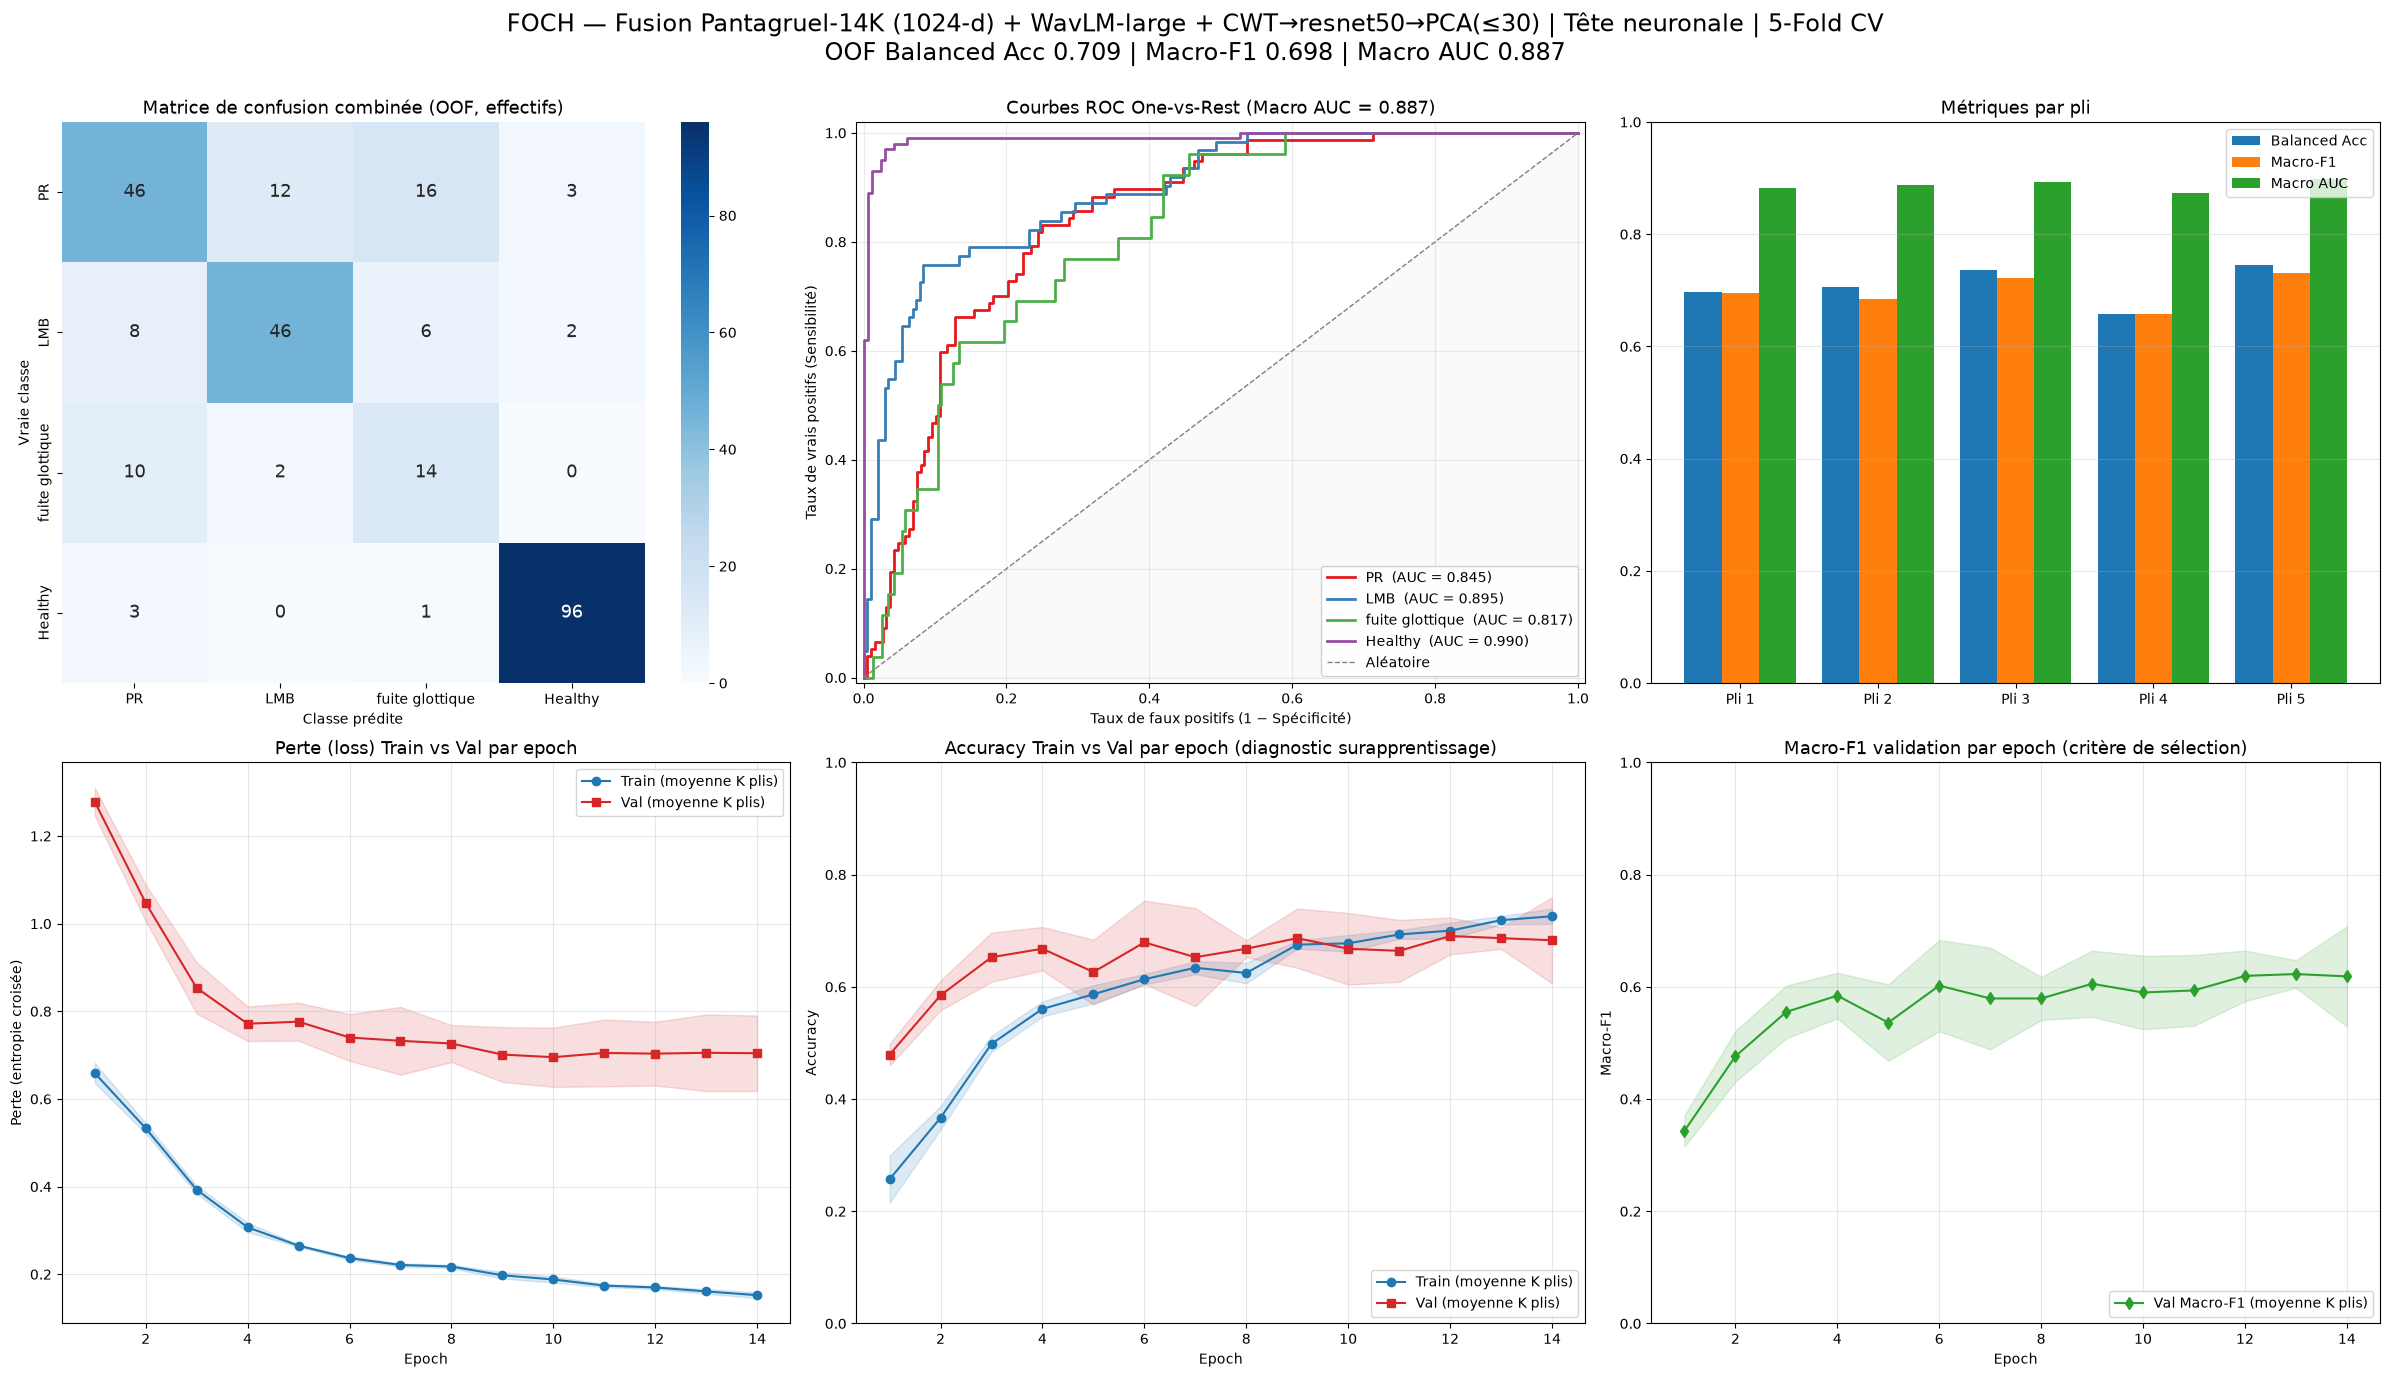


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • pantagruel_wavlm_large_cwt_cnn_neural_fusion_kfold_aug_dashboard.png
  • pantagruel_wavlm_large_cwt_cnn_neural_fusion_kfold_aug_metrics.json
  • pantagruel_wavlm_large_cwt_cnn_neural_fusion_kfold_aug_confusion.csv
  • pantagruel_wavlm_large_cwt_cnn_neural_fusion_kfold_aug_fold_metrics.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold) + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Titre dynamique : reflète le preset et le mode réellement actifs ─────────
_arch_names = []
if USE_PANTAGRUEL: _arch_names.append(f'Pantagruel-14K ({PANTAGRUEL_EMB_DIM}-d)')
if WAVLM_VARIANT:   _arch_names.append(f'WavLM-{WAVLM_VARIANT.replace("_", "-")}')
if USE_CWT_CNN:     _arch_names.append(f'CWT→{RESNET_VARIANT}→PCA(≤{PCA_MAX_COMPONENTS})')
_arch_txt = ' + '.join(_arch_names) if _arch_names else BACKBONE
_mode_txt = ('Tête neuronale' if CLASSIFIER_MODE == 'neural_fusion'
             else f'{CLASSICAL_MODEL} (Optuna)')

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)

# ── Tableau de bord 2×3 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(f'FOCH — Fusion {_arch_txt} | {_mode_txt} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=17)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 13})
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)', fontsize=13)
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01]); axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})', fontsize=13)
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [0, 2] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[0, 2].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[0, 2].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[0, 2].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[0, 2].set_title('Métriques par pli', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y', alpha=0.3)

if CLASSIFIER_MODE == 'neural_fusion':
    # ── [1, 0] Perte (loss) Train vs Val par epoch ────────────────────────────
    assert 'fold_train_loss' in globals() and len(fold_train_loss), \
        "fold_train_loss manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
    min_ep_loss = min(min(len(h) for h in fold_train_loss),
                       min(len(h) for h in fold_curves))
    tr_loss = np.array([h[:min_ep_loss] for h in fold_train_loss])
    va_loss = np.array([h[:min_ep_loss] for h in fold_curves])
    ep_loss = np.arange(1, min_ep_loss + 1)
    axes[1, 0].plot(ep_loss, tr_loss.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
    axes[1, 0].fill_between(ep_loss, tr_loss.mean(0) - tr_loss.std(0), tr_loss.mean(0) + tr_loss.std(0),
                            color='#1f77b4', alpha=0.15)
    axes[1, 0].plot(ep_loss, va_loss.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
    axes[1, 0].fill_between(ep_loss, va_loss.mean(0) - va_loss.std(0), va_loss.mean(0) + va_loss.std(0),
                            color='#d62728', alpha=0.15)
    axes[1, 0].set_title('Perte (loss) Train vs Val par epoch', fontsize=13)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Perte (entropie croisée)')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)

    # ── [1, 1] Diagnostic de surapprentissage : Train vs Val accuracy / epoch ─
    assert 'fold_train_acc' in globals() and 'fold_val_acc' in globals() \
            and len(fold_train_acc) and len(fold_val_acc), \
        "fold_train_acc/fold_val_acc manquant — réexécutez la Cellule 7 pour régénérer l'historique."
    min_ep = min(min(len(h) for h in fold_train_acc),
                 min(len(h) for h in fold_val_acc))
    tr = np.array([h[:min_ep] for h in fold_train_acc])
    va = np.array([h[:min_ep] for h in fold_val_acc])
    ep = np.arange(1, min_ep + 1)
    axes[1, 1].plot(ep, tr.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
    axes[1, 1].fill_between(ep, tr.mean(0) - tr.std(0), tr.mean(0) + tr.std(0),
                            color='#1f77b4', alpha=0.15)
    axes[1, 1].plot(ep, va.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
    axes[1, 1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                            color='#d62728', alpha=0.15)
    axes[1, 1].set_title('Accuracy Train vs Val par epoch (diagnostic surapprentissage)', fontsize=13)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend(loc='lower right')
    axes[1, 1].grid(True, alpha=0.3)

    # ── [1, 2] Macro-F1 de validation par epoch (critère de sélection) ────────
    min_ep_f1 = min(len(h) for h in fold_val_f1)
    vf1 = np.array([h[:min_ep_f1] for h in fold_val_f1])
    ep_f1 = np.arange(1, min_ep_f1 + 1)
    axes[1, 2].plot(ep_f1, vf1.mean(0), 'd-', color='#2ca02c', label='Val Macro-F1 (moyenne K plis)')
    axes[1, 2].fill_between(ep_f1, vf1.mean(0) - vf1.std(0), vf1.mean(0) + vf1.std(0),
                            color='#2ca02c', alpha=0.15)
    axes[1, 2].set_title('Macro-F1 validation par epoch (critère de sélection)', fontsize=13)
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Macro-F1')
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].legend(loc='lower right')
    axes[1, 2].grid(True, alpha=0.3)
else:
    # Mode classical_ml : pas de courbes d'epoch (aucun entraînement par
    # gradient) — [1,0] trace l'historique de la recherche Optuna à la place ;
    # [1,1]/[1,2] restent vides avec une note explicite.
    _trial_vals = [t.value for t in study.trials if t.value is not None]
    axes[1, 0].plot(range(1, len(_trial_vals) + 1), _trial_vals, 'o-', color='#6A5ACD', ms=3)
    axes[1, 0].axhline(study.best_value, color='#d62728', linestyle='--', label=f'Meilleur = {study.best_value:.3f}')
    axes[1, 0].set_title(f'Historique Optuna ({CLASSICAL_MODEL}, {N_TRIALS_OPTUNA} essais)', fontsize=13)
    axes[1, 0].set_xlabel('Essai')
    axes[1, 0].set_ylabel('Balanced Acc (moyenne CV)')
    axes[1, 0].legend(loc='lower right')
    axes[1, 0].grid(True, alpha=0.3)
    for _ax in (axes[1, 1], axes[1, 2]):
        _ax.axis('off')
        _ax.text(0.5, 0.5, 'N/A — classifieur classique\n(pas de courbes d\'epoch)',
                 ha='center', va='center', fontsize=12, color='grey')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_txt,
    'preset':                 BACKBONE,
    'classifier_mode':        CLASSIFIER_MODE,
    'classical_model':        CLASSICAL_MODEL if CLASSIFIER_MODE == 'classical_ml' else None,
    'branches':               {'pantagruel': USE_PANTAGRUEL, 'wavlm': WAVLM_VARIANT, 'cwt_cnn': USE_CWT_CNN},
    'pantagruel_emb_dim':     int(PANTAGRUEL_EMB_DIM),
    'wavlm_emb_dim':          int(WAVLM_EMB_DIM),
    'cnn_backbone':           RESNET_VARIANT if USE_CWT_CNN else None,
    'cnn_emb_dim_raw':        int(RESNET_EMB_DIM) if USE_CWT_CNN else 0,
    'cwt_wavelet':            CWT_WAVELET if USE_CWT_CNN else None,
    'cwt_freq_range_hz':      [CWT_FREQ_MIN, CWT_FREQ_MAX] if USE_CWT_CNN else None,
    'pca_variance_target':    PCA_VARIANCE_TARGET if USE_CWT_CNN else None,
    'pca_max_components':     PCA_MAX_COMPONENTS if USE_CWT_CNN else None,
    'pca_whiten':             PCA_WHITEN if USE_CWT_CNN else None,
    'pca_stats_per_fold':     fold_cnn_pca_stats,
    'encoders_frozen':        True,
    'optuna_best_params':     (study.best_params if CLASSIFIER_MODE == 'classical_ml' else None),
    'optuna_n_trials':        (N_TRIALS_OPTUNA if CLASSIFIER_MODE == 'classical_ml' else None),
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
    'training_time_seconds':  TOTAL_TRAIN_TIME_S,
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')


### 8b. Journal persistant des runs (branches, augmentations, métriques)

Ajoute une ligne à `runs_log.csv` (même dossier que ce notebook) à chaque exécution — lecture-concaténation-réécriture, jamais un append brut, `run_id` auto-incrémenté. Colonnes communes aux runs déjà journalisés (`run_id`, `timestamp`, `run_name`, `preset`, `aug_types_enabled`, `k_folds`, métriques OOF/moyennes, `training_time_seconds`, `metrics_json_path`, `notes`) + colonnes propres à ce notebook (`cnn_backbone`, `pca_*`, `classifier_mode`, `classical_model`, `optuna_*`) — repris de `13_0_foch_test_cwt_rnet.ipynb`, absent du notebook 11.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════════
# Cellule 8b — Journal persistant des runs (branches, augmentations, métriques)
# ══════════════════════════════════════════════════════════════════════════════════
import datetime
import os
from pathlib import Path

# ── Résolution du dossier du notebook (même dossier que ce .ipynb) ─────────────
def _resolve_notebook_dir():
    candidates = [Path.cwd(), Path.cwd() / 'cwt_test', Path.cwd().parent / 'cwt_test']
    candidates.append(Path(r'C:/Users/AdminIA/Desktop/Classif_Aug/cwt_test'))
    for candidate in candidates:
        if (candidate / '14_0_foch_test_cnn_pca.ipynb').exists():
            return candidate.resolve()
    return Path.cwd().resolve()


NOTEBOOK_DIR = _resolve_notebook_dir()
RUNS_LOG_PATH = os.path.join(str(NOTEBOOK_DIR), 'runs_log.csv')

# ── Une ligne = un run ───────────────────────────────────────────────────────
run_record = {
    'run_id':                     None,   # rempli plus bas (compteur du journal)
    'timestamp':                  datetime.datetime.now().isoformat(timespec='seconds'),
    'run_name':                   RUN_NAME,
    'preset':                     BACKBONE,
    'classifier_mode':            CLASSIFIER_MODE,
    'classical_model':            CLASSICAL_MODEL if CLASSIFIER_MODE == 'classical_ml' else None,
    'use_pantagruel':             USE_PANTAGRUEL,
    'wavlm_variant':               WAVLM_VARIANT,
    'use_cwt_cnn':                 USE_CWT_CNN,
    'cnn_backbone':                RESNET_VARIANT if USE_CWT_CNN else None,
    'cnn_emb_dim_raw':             RESNET_EMB_DIM if USE_CWT_CNN else None,
    'pca_variance_target':         PCA_VARIANCE_TARGET if USE_CWT_CNN else None,
    'pca_max_components':          PCA_MAX_COMPONENTS if USE_CWT_CNN else None,
    'cnn_pca_n_components_last_fold': int(fold_df['cnn_pca_n_components'].iloc[-1]) if 'cnn_pca_n_components' in fold_df.columns else None,
    'aug_types_enabled':           '+'.join(sorted(AUG_TYPES_ENABLED)) if AUG_TYPES_ENABLED else 'aucune',
    'finetune_scope':              'tete_fusion (encodeurs geles)' if CLASSIFIER_MODE == 'neural_fusion' else 'aucun (features gelees + classifieur classique)',
    'k_folds':                     K_FOLDS,
    'max_len_s':                   MAX_LEN_S,
    'batch_size':                  BATCH_SIZE if CLASSIFIER_MODE == 'neural_fusion' else None,
    'accum_steps':                 ACCUM_STEPS if CLASSIFIER_MODE == 'neural_fusion' else None,
    'effective_batch':             (BATCH_SIZE * ACCUM_STEPS) if CLASSIFIER_MODE == 'neural_fusion' else None,
    'epochs_max':                  EPOCHS if CLASSIFIER_MODE == 'neural_fusion' else None,
    'lr':                          LR if CLASSIFIER_MODE == 'neural_fusion' else None,
    'weight_decay':                WEIGHT_DECAY if CLASSIFIER_MODE == 'neural_fusion' else None,
    'dropout':                     DROPOUT if CLASSIFIER_MODE == 'neural_fusion' else None,
    'hidden_dim':                  HIDDEN_DIM if CLASSIFIER_MODE == 'neural_fusion' else None,
    'input_dropout':               INPUT_DROPOUT if CLASSIFIER_MODE == 'neural_fusion' else None,
    'focal_gamma':                 FOCAL_GAMMA if CLASSIFIER_MODE == 'neural_fusion' else None,
    'optuna_n_trials':             N_TRIALS_OPTUNA if CLASSIFIER_MODE == 'classical_ml' else None,
    'optuna_best_params':          str(study.best_params) if CLASSIFIER_MODE == 'classical_ml' else None,
    'n_total':                     int(len(df)),
    'n_healthy_target':            N_HEALTHY,
    'oof_balanced_accuracy':       oof_bal,
    'oof_macro_f1':                oof_mf1,
    'oof_macro_auc_ovr':           oof_auc,
    'mean_balanced_accuracy':      mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':               mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':          mean_auc, 'std_macro_auc_ovr':     std_auc,
    'training_time_seconds':       TOTAL_TRAIN_TIME_S,
    'metrics_json_path':           os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'),
    'notes':                       '',   # champ libre — à compléter à la main après coup si besoin
}

new_row = pd.DataFrame([run_record])

# ── Lecture-concaténation-réécriture, jamais un append brut ────────────────
if os.path.isfile(RUNS_LOG_PATH):
    runs_log = pd.read_csv(RUNS_LOG_PATH)
    if 'run_id' not in runs_log.columns:
        runs_log['run_id'] = range(1, len(runs_log) + 1)
    next_run_id = int(runs_log['run_id'].max()) + 1 if len(runs_log) else 1
    new_row['run_id'] = next_run_id
    runs_log = pd.concat([runs_log, new_row], ignore_index=True, sort=False)
else:
    new_row['run_id'] = 1
    runs_log = new_row

runs_log.to_csv(RUNS_LOG_PATH, index=False)

print(f"Run \"{RUN_NAME}\" (id {int(new_row['run_id'].iloc[0])}) ajouté au journal "
      f"— {len(runs_log)} run(s) au total → {RUNS_LOG_PATH}")
runs_log[['run_id', 'timestamp', 'run_name', 'preset', 'classifier_mode',
          'oof_balanced_accuracy', 'oof_macro_f1', 'oof_macro_auc_ovr',
          'training_time_seconds']].tail(5)


Run "pantagruel_wavlm_large_cwt_cnn_neural_fusion_kfold_aug" (id 3) ajouté au journal — 3 run(s) au total → C:\Users\AdminIA\Desktop\Classif_Aug\cwt_test\runs_log.csv


,run_id,timestamp,run_name,preset,classifier_mode,oof_balanced_accuracy,oof_macro_f1,oof_macro_auc_ovr,training_time_seconds
0,1,2026-09-03T13:24:36,wavlm_bp_cwt_rnet_kfold_aug,wavlm_bp_cwt_rnet,NaN,0.643834,0.618767,0.865873,1496.987454
1,2,2026-09-03T13:41:16,cwt_rnet_solo_kfold_aug,cwt_rnet_solo,NaN,0.649710,0.603378,0.870554,796.938920
2,3,2026-09-04T12:26:06,pantagruel_wavlm_large_cwt_cnn_neural_fusion_k...,pantagruel_wavlm_large_cwt_cnn,neural_fusion,0.709450,0.698164,0.886784,3234.532626


## 9. Synthèse et prochaines étapes

**Ce que fait ce notebook.**

- **Copie de `11_0_foch_test_cwt_dinov2.ipynb`** dont la partie représentation change : retrait des branches résidu vocodeur (Vocos) et Vision Transformer (DINOv2-Large), remplacées par un CNN ImageNet classique (torchvision, `RESNET_VARIANT`) sur le même scalogramme CWT, réduit par PCA fold-safe. Protocole d'évaluation strictement inchangé (`StratifiedKFold` 5 plis patient-level, augmentation train-only, `FocalLoss` pondérée par pli).
- **Trois branches** : Pantagruel `speech-large-14K` (gelé), WavLM-**Large** (gelé, PAS Base-Plus — capacité supérieure, 1024-d/24 couches), CNN ImageNet gelé sur scalogramme CWT (réduit par PCA).
- **La CNN est sortie du modèle neuronal** : contrairement à Pantagruel/WavLM (calculés en direct dans `forward()`), la CNN est gelée et déterministe par fichier — elle est extraite UNE SEULE FOIS pour tout le corpus (mise en cache par `filepath`, Cellule 4), pas recalculée à chaque batch/epoch. Le modèle (Cellule 6) ne contient donc AUCUN sous-module CNN : `cnn_vec` lui arrive déjà réduit.
- **PCA fold-safe** : `StandardScaler` puis `PCA` (95 % de variance expliquée, plafond dur `PCA_MAX_COMPONENTS=30`), ajustés EXCLUSIVEMENT sur le train du pli courant (jamais sur la validation ni le dataset complet) — même discipline que les statistiques de résidu vocodeur du notebook 11, appliquée à un embedding CNN plutôt qu'à 6 scalaires faits main.
- **Deux modes de classifieur (`CLASSIFIER_MODE`)** :
  - `'neural_fusion'` [DÉFAUT] — tête de fusion neuronale du template, entrée = Pantagruel brut + WavLM-Large brut + CNN réduit par PCA. Seule cette PCA est fold-safe côté neuronal ; Pantagruel/WavLM restent bruts (dimension déjà raisonnable).
  - `'classical_ml'` — classifieur classique (`CLASSICAL_MODEL` : Random Forest / XGBoost / SVM) tuné en Optuna/TPE (style `10_1_foch_residual_wavelet_svm_optuna.ipynb`), sur la concaténation des TROIS embeddings réduits par PCA fold-safe. Recherche d'hyperparamètres en deux temps : (a) étude Optuna maximisant la balanced accuracy moyenne CV ; (b) un second passage par pli avec les meilleurs hyperparamètres pour produire de VRAIES prédictions/probabilités OOF (l'objectif Optuna scalaire seul ne les fournit pas).
- **Journal persistant** (`runs_log.csv`, Cellule 8b, nouveau par rapport au notebook 11 — repris de `13_0_foch_test_cwt_rnet.ipynb`) : chaque exécution ajoute une ligne (append fold-safe, lecture-concat-réécriture), colonnes communes aux runs existants + colonnes propres à ce notebook (`cnn_backbone`, `pca_*`, `classifier_mode`, `classical_model`, `optuna_*`).

**Décisions prises pendant l'implémentation, à relire avant un premier run réel.**

- **CNN hors du modèle plutôt qu'en sous-module gelé** : plus rapide (un seul forward CNN par fichier pour tout le run, pas un par batch/epoch) et cohérent avec le pattern déjà en place pour le résidu vocodeur du notebook 11 — mais casse la symétrie « toutes les branches vivent dans `MultiBranchFusion` » des notebooks 11/12. `cnn_dim` est donc un paramètre du constructeur (résolu par pli), pas une constante globale comme `PANTAGRUEL_EMB_DIM`/`WAVLM_EMB_DIM`.
- **Portée de la PCA selon le mode** : seule la CNN est réduite en `neural_fusion` (Pantagruel/WavLM restent bruts) ; les trois branches le sont en `classical_ml` (un classifieur classique n'a pas de régularisation par gradient pour absorber ~3800-d bruts sur ~212 échantillons/pli).
- **`PCA_WHITEN=True`** — variance unitaire par composante, pensé pour le mode `classical_ml` (évite un second `StandardScaler` après la PCA) ; neutre pour la tête neuronale.
- `RESNET_VARIANT='resnet50'` (2048-d, ImageNet1K_V2) par défaut — changer cette constante ne touche aucune autre cellule (dimension, taille d'image, normalisation résolues à l'exécution).

**Pistes d'amélioration (non retenues dans cette itération, à explorer si le besoin se confirme).**

- Comparer `PCA_MAX_COMPONENTS` (actuellement 30) à d'autres plafonds — sensibilité non mesurée ici.
- `CLASSICAL_MODEL='xgboost'` nécessite le paquet `xgboost`, absent de `requirements.txt` à ce jour — à ajouter si ce sous-preset est utilisé.
- Envisager une PCA par branche même en `neural_fusion` pour Pantagruel/WavLM, si leur dimension brute s'avère elle aussi disproportionnée une fois l'augmentation prise en compte.
- `whiten=True` change l'échelle relative des composantes CNN par rapport à Pantagruel/WavLM bruts dans la tête neuronale — non comparé ici à `whiten=False`.
